# 因子選股策略回測：完整流程（取得資料 → Phase 1~4 SOP）

從資料庫取資料開始，依序執行 Phase 1（單因子健檢）→ Phase 2（F1×F2配對）→
Phase 3（加動態條件C）→ Phase 4（加估值濾網V）。

程式邏輯跟 `code/phase1_*.py`~`phase4_*.py` 完全一致（本notebook呼叫那些程式，
不是另外重寫一份），跑出來的結果跟直接用命令列執行相同。

由上而下依序執行每個 code cell 即可。


## 0. 環境設定

`code/` 底下的程式需要 import 到上層目錄的 `database.py`、`get_data.py` 等模組。


In [50]:
import sys
sys.path.insert(0, '../')

import warnings
warnings.filterwarnings('ignore')

print('目前工作目錄應為 code/ ：', __import__('os').getcwd())


目前工作目錄應為 code/ ： d:\git\stock_factor_lab\code


## 0.5 選擇市場

**整份 notebook 只需要改下面這一格**，其餘所有 cell 都會自動套用，不用再逐格修改 `--market`。


In [51]:
MARKET = 'US'  # 'TW' 或 'US'，改這裡切換整份 notebook 要跑哪個市場


## 1. 取得資料

回測引擎透過 `fcv_core.MarketData` 一次載入某個市場的價量+財報資料，
Phase 1~4 重複使用這份已載入的資料。

`MarketData` 做的事：
1. 呼叫 `get_data.Data(market=...)` 從資料庫抓股價、財報、因子原始資料。
2. 回測宇宙＝「有因子資料」∩「有股價資料」的股票交集。
3. 依 `start`/`end` 參數把資料裁到 in-sample 範圍（2000-01-01~2025-12-31，
   2026年之後保留當作樣本外，不用來訓練/篩選，避免用到未來資訊）。


In [52]:
from fcv_core import MarketData

md_demo = MarketData(market=MARKET, end='2025-12-31')

close = md_demo.data.get('price:close')
print('股價資料形狀（交易日 x 股票數）：', close.shape)
close.tail()


>> 載入 Data(market='US') ...
   因子宇宙=2974｜回測宇宙=2972｜起點>=2000-01-01｜終點<=2025-12-31｜交易日=6604 (2000-01-03~2025-12-31)｜耗時 269s
股價資料形狀（交易日 x 股票數）： (6604, 2972)


company_symbol,A,AA,AAL,AAMI,AAOI,AAON,AAP,AAPL,AAT,ABAT,...,ZM,ZNTL,ZS,ZSQR,ZTS,ZUMZ,ZURA,ZVRA,ZWS,ZYME
date,,,,,,,,,,,,,,,,,,,,,
2025-12-26,137.57,54.07,15.44,48.23,37.17,75.62,40.82,272.89,18.30,3.82,...,88.04,1.36,230.52,NaN,125.15,27.24,4.65,8.87,47.62,26.87
2025-12-28,137.57,54.07,15.44,48.23,37.17,75.62,40.82,272.89,18.30,3.82,...,88.04,1.36,230.52,NaN,125.15,27.24,4.65,8.87,47.62,26.87
2025-12-29,137.11,53.59,15.14,47.92,36.75,75.55,39.46,273.25,18.48,3.50,...,86.33,1.36,228.02,NaN,124.90,27.22,5.35,8.82,47.55,26.74
2025-12-30,136.80,54.21,15.33,47.39,36.02,78.46,39.23,272.57,18.45,3.36,...,86.30,1.33,227.42,NaN,125.33,26.78,5.32,8.81,47.12,26.54
2025-12-31,135.26,52.97,15.33,46.85,34.86,76.10,38.89,271.35,18.33,3.34,...,86.29,1.35,224.92,NaN,124.74,26.05,5.24,8.96,46.28,26.33


In [53]:
roe = md_demo.get_field('report:ROE')
print('ROE 資料形狀：', roe.shape if roe is not None else None)

md_demo.release()   # 釋放快取


ROE 資料形狀： (6604, 2972)


⚠️ 下面 Phase 1~4 的每個腳本都是各自獨立可執行的程式，執行時會**各自重新呼叫一次
`MarketData` 重新載入資料**，不會共用上面這個demo載入的 `md_demo`。


## 2. Phase 1：單因子線性檢定

每個候選因子單獨切成 9 個分位桶（q_band），不搭配其他因子、不加動態條件，
檢查報酬是否隨分位單調變化（Spearman ρ）。未通過線性檢定的因子不會用於後續
Phase 2~4 的 primary 因子。

因子池 20 個（PE 保留給 Phase 4 估值濾網使用，不在此因子池內）。
先 `--dry-run` 看預期跑幾個策略：


In [54]:
%run phase1_linearity.py --market $MARKET --dry-run


[2026-08-24 21:52:51] === Phase 1 線性檢定｜市場=US｜因子數=20｜分桶 N=9｜V=('v0',)（F2/C 皆關閉）｜in-sample 至 2025-12-31 ===
[2026-08-24 21:52:51]     done     US_L1_ROE_M            P1= 9 P3= 0 → 預期 9 策略
[2026-08-24 21:52:51]     done     US_L1_EPS_M            P1= 9 P3= 0 → 預期 9 策略
[2026-08-24 21:52:51]     done     US_L1_FCF_P_M          P1= 9 P3= 0 → 預期 9 策略
[2026-08-24 21:52:51]     done     US_L1_DEBTRATIO_M      P1= 9 P3= 0 → 預期 9 策略
[2026-08-24 21:52:51]     done     US_L1_REVENUE_M        P1= 9 P3= 0 → 預期 9 策略
[2026-08-24 21:52:51]     done     US_L1_EV_EBITDA_M      P1= 9 P3= 0 → 預期 9 策略
[2026-08-24 21:52:51]     done     US_L1_EV_S_M           P1= 9 P3= 0 → 預期 9 策略
[2026-08-24 21:52:51]     done     US_L1_PB_M             P1= 9 P3= 0 → 預期 9 策略
[2026-08-24 21:52:51]     done     US_L1_PS_M             P1= 9 P3= 0 → 預期 9 策略
[2026-08-24 21:52:51]     done     US_L1_P_IC_M           P1= 9 P3= 0 → 預期 9 策略
[2026-08-24 21:52:52]     done     US_L1_ROIC_M           P1= 9 P3= 0 → 預期 9 策略
[2026-08-24 21

確認數字合理後，拿掉 `--dry-run` 真的執行（9桶×20因子×2個V模式，約數百個策略，
通常數分鐘內可完成）：


In [55]:
%run phase1_linearity.py --market $MARKET


[2026-08-24 21:52:52] === Phase 1 線性檢定｜市場=US｜因子數=20｜分桶 N=9｜V=('v0',)（F2/C 皆關閉）｜in-sample 至 2025-12-31 ===
[2026-08-24 21:52:52]     done     US_L1_ROE_M            P1= 9 P3= 0 → 預期 9 策略
[2026-08-24 21:52:52]     done     US_L1_EPS_M            P1= 9 P3= 0 → 預期 9 策略
[2026-08-24 21:52:52]     done     US_L1_FCF_P_M          P1= 9 P3= 0 → 預期 9 策略
[2026-08-24 21:52:52]     done     US_L1_DEBTRATIO_M      P1= 9 P3= 0 → 預期 9 策略
[2026-08-24 21:52:52]     done     US_L1_REVENUE_M        P1= 9 P3= 0 → 預期 9 策略
[2026-08-24 21:52:52]     done     US_L1_EV_EBITDA_M      P1= 9 P3= 0 → 預期 9 策略
[2026-08-24 21:52:52]     done     US_L1_EV_S_M           P1= 9 P3= 0 → 預期 9 策略
[2026-08-24 21:52:52]     done     US_L1_PB_M             P1= 9 P3= 0 → 預期 9 策略
[2026-08-24 21:52:52]     done     US_L1_PS_M             P1= 9 P3= 0 → 預期 9 策略
[2026-08-24 21:52:52]     done     US_L1_P_IC_M           P1= 9 P3= 0 → 預期 9 策略
[2026-08-24 21:52:52]     done     US_L1_ROIC_M           P1= 9 P3= 0 → 預期 9 策略
[2026-08-24 21

用 `phase1_analyze.py` 分析健檢結果——算每個因子的 Spearman ρ、判定有沒有線性、
畫出9桶報酬曲線圖，輸出到 `../_analysis_outputs_phase1/`：


In [56]:
%run phase1_analyze.py --market $MARKET


基準 = 11.06%

載入規模參照（REVENUE_qb0）以計算重疊診斷 …
===== Phase 1 線性檢定結果 =====
            因子  Spearman_rho     p值       形狀       判定  最佳桶  最佳桶CAGR   全桶均值  贏大盤桶數  最佳桶與最小規模重疊
       REVENUE        -0.983 0.0000      單調↓     ✅ 過關    0   0.2616 0.1641      9         NaN
          EV_S        -0.983 0.0000      單調↓     ✅ 過關    0   0.2998 0.1656      9       0.094
            PB        -0.950 0.0001      單調↓     ✅ 過關    0   0.3489 0.1676      9       0.173
            PS        -0.950 0.0001      單調↓     ✅ 過關    0   0.3203 0.1649      9       0.059
          P_IC        -0.950 0.0001      單調↓     ✅ 過關    0   0.2244 0.1659      9       0.098
     EV_EBITDA        -0.933 0.0002      單調↓     ✅ 過關    1   0.3156 0.1640      8       0.237
           VOL         0.933 0.0002      單調↑     ✅ 過關    8   0.3377 0.1602      9       0.403
           EPS        -0.900 0.0009      單調↓     ✅ 過關    1   0.2574 0.1604      8       0.276
         OCF_E         0.183 0.6368 U型（兩端最好） ⚠️ 只取極端桶    8   0.2268 0.1581      9    

看結果——每個因子的線性判定表，跟9桶報酬曲線圖：

,因子,Spearman_rho,p值,形狀,判定,最佳桶,最佳桶CAGR,最差桶CAGR,全桶均值,贏大盤桶數,最佳桶與最小規模重疊,桶0,桶1,桶2,桶3,桶4,桶5,桶6,桶7,桶8
0,REVENUE,-0.983,0.0000,單調↓,✅ 過關,0,0.2616,0.1122,0.1641,9,NaN,0.2616,0.1793,0.1899,0.1606,0.1492,0.1467,0.1394,0.1379,0.1122
1,EV_S,-0.983,0.0000,單調↓,✅ 過關,0,0.2998,0.1164,0.1656,9,0.094,0.2998,0.2055,0.1734,0.1503,0.1587,0.1354,0.1308,0.1203,0.1164
2,PB,-0.950,0.0001,單調↓,✅ 過關,0,0.3489,0.1322,0.1676,9,0.173,0.3489,0.1951,0.1506,0.1380,0.1368,0.1363,0.1347,0.1322,0.1355
3,PS,-0.950,0.0001,單調↓,✅ 過關,0,0.3203,0.1123,0.1649,9,0.059,0.3203,0.1975,0.1703,0.1506,0.1426,0.1361,0.1245,0.1123,0.1297
4,P_IC,-0.950,0.0001,單調↓,✅ 過關,0,0.2244,0.1325,0.1659,9,0.098,0.2244,0.1834,0.1688,0.1718,0.1695,0.1579,0.1477,0.1369,0.1325
5,EV_EBITDA,-0.933,0.0002,單調↓,✅ 過關,1,0.3156,0.1089,0.1640,8,0.237,0.1834,0.3156,0.2045,0.1520,0.1461,0.1338,0.1141,0.1171,0.1089
6,VOL,0.933,0.0002,單調↑,✅ 過關,8,0.3377,0.1144,0.1602,9,0.403,0.1172,0.1152,0.1144,0.1223,0.1293,0.1474,0.1559,0.2027,0.3377
7,EPS,-0.900,0.0009,單調↓,✅ 過關,1,0.2574,0.0983,0.1604,8,0.276,0.1559,0.2574,0.2481,0.1683,0.1485,0.1269,0.1221,0.1184,0.0983
8,OCF_E,0.183,0.6368,U型（兩端最好）,⚠️ 只取極端桶,8,0.2268,0.1205,0.1581,9,0.088,0.2120,0.1581,0.1360,0.1205,0.1269,0.1348,0.1424,0.1657,0.2268
9,FCF_P,0.133,0.7324,U型（兩端最好）,⚠️ 只取極端桶,0,0.2942,0.1021,0.1586,7,0.301,0.2942,0.1423,0.1055,0.1021,0.1159,0.1306,0.1337,0.1729,0.2297


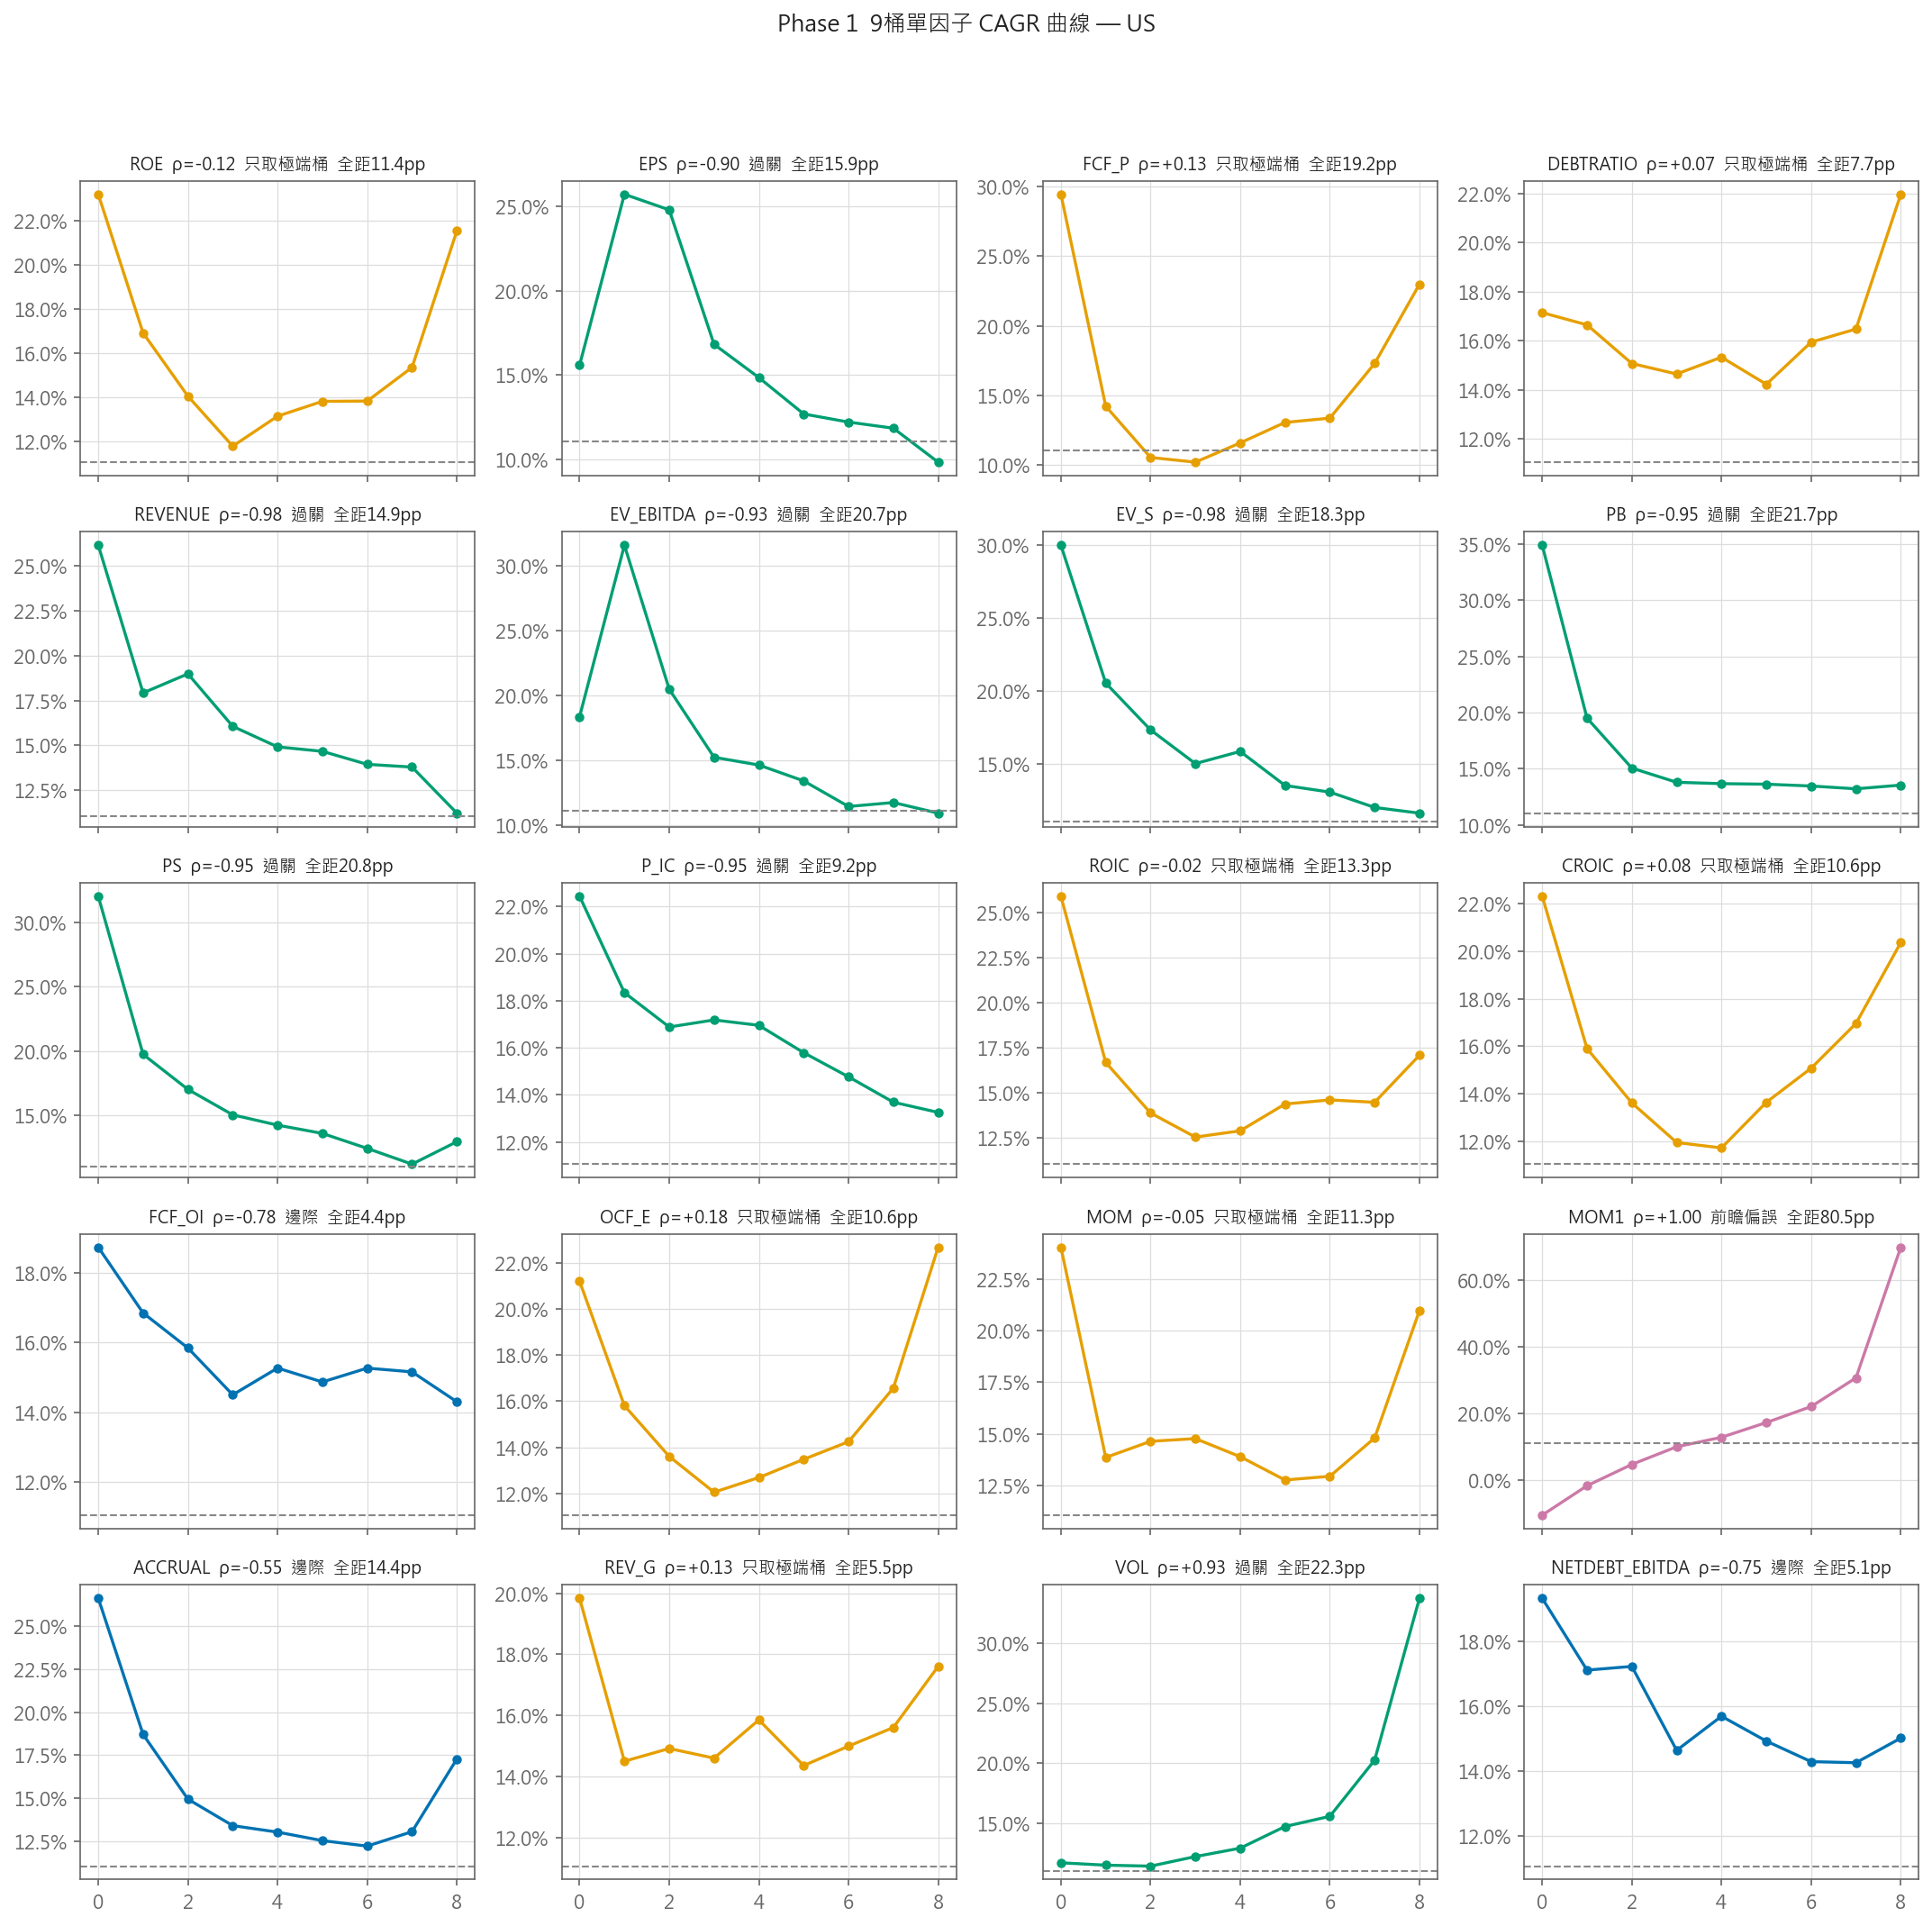

In [57]:
import pandas as pd
from IPython.display import Image, display

df = pd.read_csv(f'../_analysis_outputs_phase1/{MARKET}_phase1_linearity.csv')
display(df)
display(Image(f'../_analysis_outputs_phase1/{MARKET}_phase1_curves.png'))


## 3. Phase 2：F1×F2 不對稱配對

Phase 1 通過線性檢定的因子分成 primary（嚴格門檻）／secondary（寬鬆）。
`--variant openSec`：primary 用嚴格標準篩，secondary 全部開放。


In [58]:
%run phase2_pairing.py --market $MARKET --variant openSec --dry-run


[2026-08-24 21:53:00] === Phase 2 配對｜市場=US｜因子=19（primary 8 / secondary 19）｜分桶 N=3｜V=('v0',)（C 關閉）｜in-sample 至 2025-12-31 ===
[2026-08-24 21:53:00]     primary  ：['REVENUE', 'EV_S', 'PB', 'PS', 'P_IC', 'EV_EBITDA', 'VOL', 'EPS']
[2026-08-24 21:53:00]     secondary：['REVENUE', 'EV_S', 'PB', 'PS', 'P_IC', 'EV_EBITDA', 'VOL', 'EPS', 'OCF_E', 'FCF_P', 'REV_G', 'ROE', 'CROIC', 'DEBTRATIO', 'MOM', 'ROIC', 'FCF_OI', 'NETDEBT_EBITDA', 'ACCRUAL']
[2026-08-24 21:53:00]     P1 條件數=57｜單因子=57｜跨因子配對=1539｜預期共 1596 策略
[2026-08-24 21:53:00]     done  US_L2_all_M
[2026-08-24 21:53:00] dry-run：不執行。


拿掉 `--dry-run` 真的執行（F1×F2 兩兩配對，策略數比 Phase 1 多，通常數十分鐘等級）：


In [59]:
%run phase2_pairing.py --market $MARKET --variant openSec


[2026-08-24 21:53:00] === Phase 2 配對｜市場=US｜因子=19（primary 8 / secondary 19）｜分桶 N=3｜V=('v0',)（C 關閉）｜in-sample 至 2025-12-31 ===
[2026-08-24 21:53:00]     primary  ：['REVENUE', 'EV_S', 'PB', 'PS', 'P_IC', 'EV_EBITDA', 'VOL', 'EPS']
[2026-08-24 21:53:00]     secondary：['REVENUE', 'EV_S', 'PB', 'PS', 'P_IC', 'EV_EBITDA', 'VOL', 'EPS', 'OCF_E', 'FCF_P', 'REV_G', 'ROE', 'CROIC', 'DEBTRATIO', 'MOM', 'ROIC', 'FCF_OI', 'NETDEBT_EBITDA', 'ACCRUAL']
[2026-08-24 21:53:00]     P1 條件數=57｜單因子=57｜跨因子配對=1539｜預期共 1596 策略
[2026-08-24 21:53:00]     done  US_L2_all_M
[2026-08-24 21:53:00] 已完成（且因子池相同），無待跑。


In [60]:
%run phase2_analyze.py --market $MARKET --variant openSec


變體＝openSec：修正版：primary 維持 Phase 1 過關者，secondary 開放全部
  primary  (8)：['REVENUE', 'EV_S', 'PB', 'PS', 'P_IC', 'EV_EBITDA', 'VOL', 'EPS']
  secondary(19)：['REVENUE', 'EV_S', 'PB', 'PS', 'P_IC', 'EV_EBITDA', 'VOL', 'EPS', 'OCF_E', 'FCF_P', 'REV_G', 'ROE', 'CROIC', 'DEBTRATIO', 'MOM', 'ROIC', 'FCF_OI', 'NETDEBT_EBITDA', 'ACCRUAL']
基準＝11.06%
門檻：primary 需 > 基準+2%｜secondary 需 > 基準−1%｜配對退步容忍 0.5%｜平均持股數 ≥ 10

讀入 1596 個策略（單因子 57／配對 1539）
計算持股數三項指標（平均／覆蓋率／p10）…

可當 primary 的 (因子,桶)：19 個
       F1  k1     CAGR      贏大盤      平均持股數
EV_EBITDA   0 0.241595 0.131039 586.586538
      VOL   2 0.238349 0.127792 583.730769
       PB   0 0.233229 0.122672 587.663462
       PS   0 0.231675 0.121119 578.958333
     EV_S   0 0.228473 0.117917 578.958333
      EPS   0 0.225454 0.114898 588.769231
  REVENUE   0 0.214197 0.103640 589.250000
     P_IC   0 0.195025 0.084469 587.634615
     P_IC   1 0.169971 0.059415 587.974359
  REVENUE   1 0.153803 0.043247 589.560897
     EV_S   1 0.151505 0.040948 579.240385
    

看結果——配對後的體質檢查表（前10筆），跟配對增益分布圖：

,strategy,primary,secondary,CAGR,primary_solo_CAGR,配對增益,max_drawdown,win_ratio,平均持股數,持股月份覆蓋率,持股數p10,晉升,未過原因
0,REVENUE_qb0of3__PS_qb0of3__None__v0,PS_qb0,REVENUE_qb0,0.434885,0.231675,0.203210,-0.522394,0.635106,93.842949,1.00000,57.1,True,NaN
1,REVENUE_qb0of3__EV_S_qb0of3__None__v0,EV_S_qb0,REVENUE_qb0,0.391050,0.228473,0.162576,-0.569995,0.629002,116.333333,1.00000,64.0,True,NaN
2,EPS_qb0of3__ROE_qb2of3__None__v0,EPS_qb0,ROE_qb2,0.386329,0.225454,0.160875,-0.454847,0.508062,64.317308,1.00000,49.0,True,NaN
3,PB_qb0of3__VOL_qb2of3__None__v0,VOL_qb2,PB_qb0,0.347650,0.238349,0.109301,-0.622390,0.577637,213.342949,1.00000,130.0,True,NaN
4,EV_S_qb0of3__EPS_qb0of3__None__v0,EV_S_qb0,EPS_qb0,0.334982,0.228473,0.106508,-0.635453,0.591193,171.413462,1.00000,125.0,True,NaN
5,EV_S_qb2of3__PS_qb0of3__None__v0,PS_qb0,EV_S_qb2,0.332476,0.231675,0.100801,-0.700706,0.604215,11.451613,0.99359,4.0,True,NaN
6,PS_qb0of3__EPS_qb0of3__None__v0,PS_qb0,EPS_qb0,0.328448,0.231675,0.096773,-0.644218,0.593979,179.493590,1.00000,127.0,True,NaN
7,PS_qb0of3__VOL_qb2of3__None__v0,VOL_qb2,PS_qb0,0.325828,0.238349,0.087479,-0.644395,0.574328,223.730769,1.00000,138.1,True,NaN
8,EV_S_qb0of3__VOL_qb2of3__None__v0,VOL_qb2,EV_S_qb0,0.319934,0.238349,0.081585,-0.623137,0.572964,217.384615,1.00000,145.1,True,NaN
9,PB_qb0of3__ROE_qb2of3__None__v0,PB_qb0,ROE_qb2,0.318867,0.233229,0.085638,-0.489034,0.571033,92.903846,1.00000,59.0,True,NaN


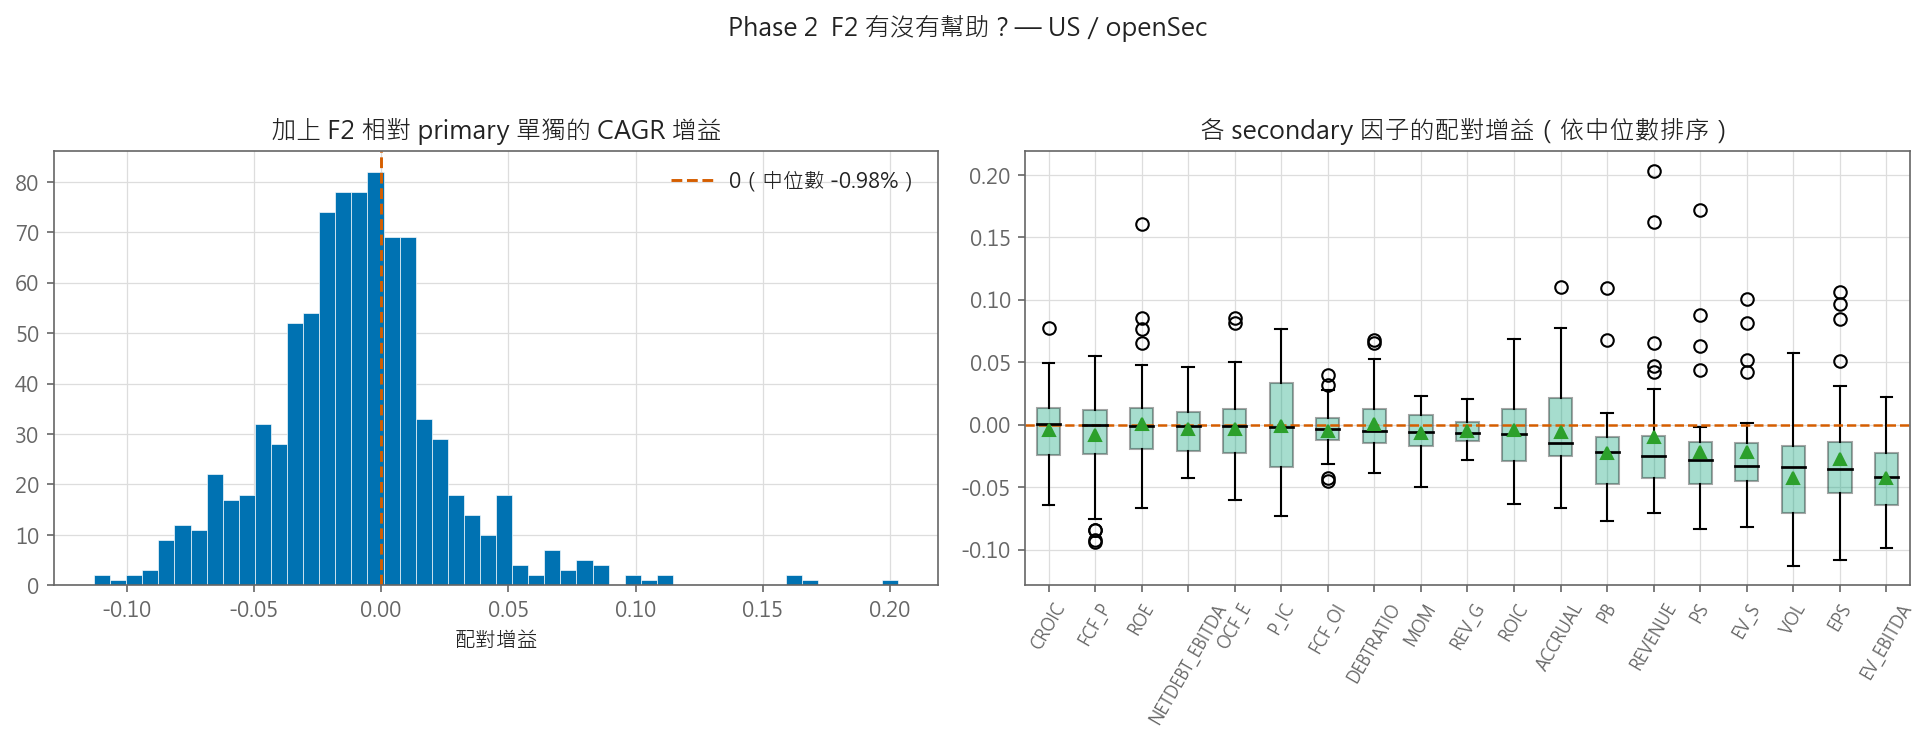

In [61]:
df = pd.read_csv(f'../_analysis_outputs_phase2/{MARKET}_L2_openSec_體質檢查表.csv')
display(df.head(10))
display(Image(f'../_analysis_outputs_phase2/{MARKET}_L2_openSec_pairing_gain.png'))


## 4. Phase 3：加入動態條件 C

在 Phase 2 通過配對的 F1×F2 策略上，疊加 20 種動態條件 C（衍生自 ROE/EPS/FCF_P，
例如「較上季升」「近N季最高」等時序條件），測試加入時間點篩選後績效是否提升。


In [62]:
%run phase3_conditions.py --market $MARKET --variant openSec --dry-run


[2026-08-24 21:59:14] === Phase 3 加入 C｜市場=US｜in-sample 至 2025-12-31 ===
[2026-08-24 21:59:14]     F 白名單（Phase 2 晉升）=235（單因子 19 / 配對 216）
[2026-08-24 21:59:14]     P1 條件=57｜C=20（+None=21 種 C 狀態）｜V=('v0',)
[2026-08-24 21:59:14]     預期共 4935 策略
[2026-08-24 21:59:14]     done  US_L3_openSec_M
[2026-08-24 21:59:14] dry-run：不執行。


拿掉 `--dry-run` 真的執行（策略數再乘上20種C條件，是四個階段中最耗時的一段，
可能要數小時）：


In [63]:
%run phase3_conditions.py --market $MARKET --variant openSec


[2026-08-24 21:59:14] === Phase 3 加入 C｜市場=US｜in-sample 至 2025-12-31 ===
[2026-08-24 21:59:14]     F 白名單（Phase 2 晉升）=235（單因子 19 / 配對 216）
[2026-08-24 21:59:14]     P1 條件=57｜C=20（+None=21 種 C 狀態）｜V=('v0',)
[2026-08-24 21:59:14]     預期共 4935 策略
[2026-08-24 21:59:14]     done  US_L3_openSec_M
[2026-08-24 21:59:14] 已完成，無待跑。


In [64]:
%run phase3_analyze.py --market $MARKET --variant openSec


基準 = 11.06%｜變體 = openSec｜持股數門檻 ≥ 10

讀入 4935 個策略｜F 組合 235 個｜C 狀態 21 種
依 Phase 2（openSec／universe）體質檢查表篩選：F 組合 235 → 235，策略 4935 個
計算平均每月持股數 …

===== A. 各 C 的價值（控制 F 後，相對同 F 的 None 基準）=====
 C編號                                C   C來源  增益中位數   增益平均 增益為正比例 CAGR中位數  持股數中位數   n
   9                C9_EPS_DYN_riseq2   EPS +2.55% +2.57%  81.7%  26.55%    97.9 235
  14      C14_EPS_DYN_ytdavg_gt_lyavg   EPS +1.91% +2.13%  73.2%  25.72%   103.3 235
  12                  C12_EPS_DYN_yoy   EPS +1.69% +2.51%  75.3%  25.91%   100.1 235
  10                C10_EPS_DYN_qmax4   EPS +1.64% +2.74%  66.0%  25.80%    59.3 235
  13   C13_EPS_DYN_ytdavg_gt_lyytdavg   EPS +1.51% +1.72%  68.9%  25.43%   104.0 235
  11                C11_EPS_DYN_qmax8   EPS +1.42% +3.53%  61.3%  25.15%    35.0 235
   8                C8_EPS_DYN_riseq1   EPS +1.10% +1.82%  74.9%  25.54%    96.5 235
   5                   C5_ROE_DYN_yoy   ROE +0.48% +0.55%  58.3%  23.94%    88.6 235
   1                C1_ROE_DYN_riseq1   ROE +0

看結果——加C後的候選策略表（前10筆，依CAGR排序），跟C條件增益圖：

,strategy,F組合,C,CAGR,None基準CAGR,C增益,max_drawdown,win_ratio,daily_sharpe,平均持股數
0,PB_qb0of3__EPS_qb0of3__C11_EPS_DYN_qmax8__v0,PB_qb0of3__EPS_qb0of3,C11_EPS_DYN_qmax8,0.640985,0.317951,0.323034,-0.453438,0.569231,5.95,16.388316
1,REVENUE_qb0of3__PS_qb0of3__C11_EPS_DYN_qmax8__v0,REVENUE_qb0of3__PS_qb0of3,C11_EPS_DYN_qmax8,0.591204,0.434885,0.156319,-0.389605,0.609195,6.72,16.579310
2,EPS_qb0of3__ACCRUAL_qb0of3__C11_EPS_DYN_qmax8__v0,EPS_qb0of3__ACCRUAL_qb0of3,C11_EPS_DYN_qmax8,0.560891,0.260735,0.300156,-0.494012,0.536033,8.56,22.615120
3,EV_S_qb0of3__EPS_qb0of3__C11_EPS_DYN_qmax8__v0,EV_S_qb0of3__EPS_qb0of3,C11_EPS_DYN_qmax8,0.549509,0.334982,0.214527,-0.586201,0.580262,4.21,11.754325
4,P_IC_qb0of3__EPS_qb0of3__C10_EPS_DYN_qmax4__v0,P_IC_qb0of3__EPS_qb0of3,C10_EPS_DYN_qmax4,0.539486,0.300461,0.239025,-0.728427,0.563998,6.34,22.865132
5,REVENUE_qb0of3__PS_qb0of3__C9_EPS_DYN_riseq2__v0,REVENUE_qb0of3__PS_qb0of3,C9_EPS_DYN_riseq2,0.532159,0.434885,0.097274,-0.586272,0.580981,8.08,49.165584
6,EPS_qb0of3__ROE_qb2of3__C11_EPS_DYN_qmax8__v0,EPS_qb0of3__ROE_qb2of3,C11_EPS_DYN_qmax8,0.519752,0.386329,0.133423,-0.644120,0.565269,6.92,12.319588
7,REVENUE_qb0of3__PS_qb0of3__C14_EPS_DYN_ytdavg_...,REVENUE_qb0of3__PS_qb0of3,C14_EPS_DYN_ytdavg_gt_lyavg,0.519159,0.434885,0.084274,-0.469156,0.599571,7.26,48.630000
8,REVENUE_qb0of3__PS_qb0of3__C12_EPS_DYN_yoy__v0,REVENUE_qb0of3__PS_qb0of3,C12_EPS_DYN_yoy,0.515551,0.434885,0.080666,-0.500687,0.579325,7.16,48.830000
9,REVENUE_qb0of3__PS_qb0of3__C10_EPS_DYN_qmax4__v0,REVENUE_qb0of3__PS_qb0of3,C10_EPS_DYN_qmax4,0.513791,0.434885,0.078905,-0.582926,0.590071,7.60,28.868852


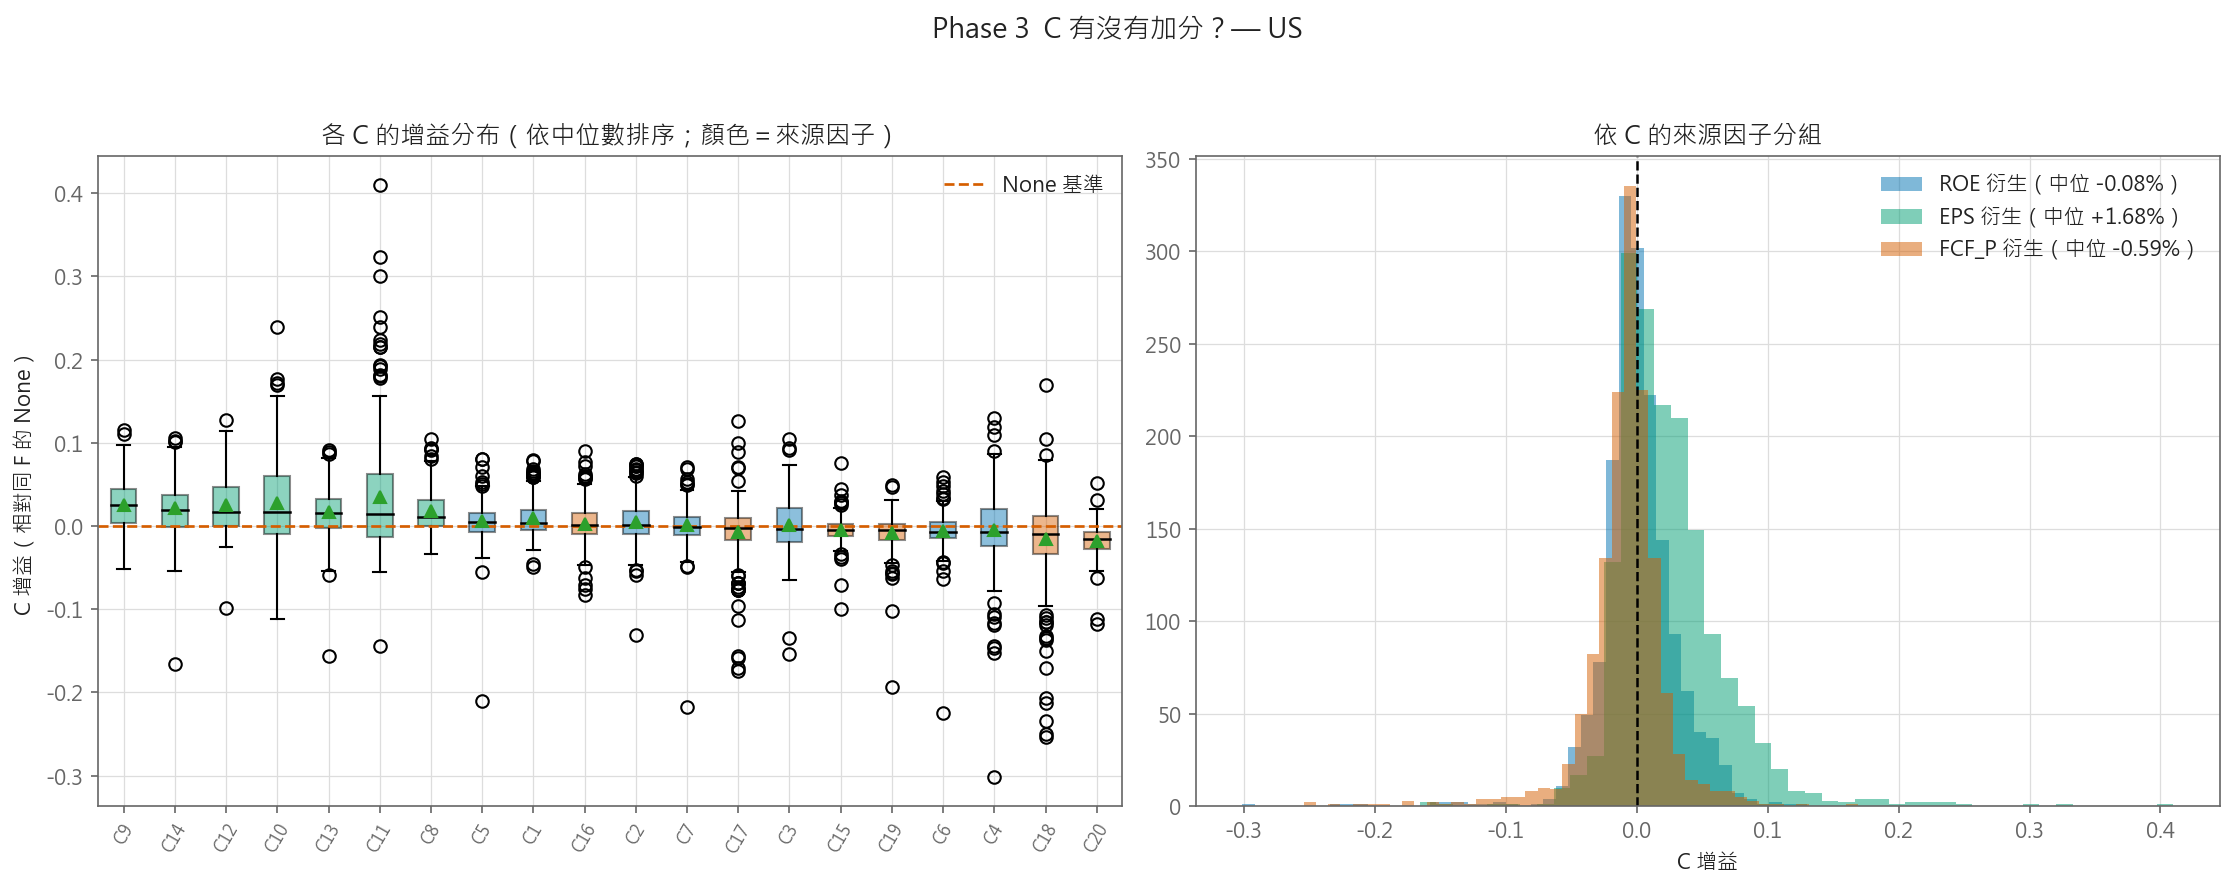

In [65]:
df = pd.read_csv(f'../_analysis_outputs_phase3/{MARKET}_L3_openSec_candidate_strategies.csv')
display(df.sort_values('CAGR', ascending=False).head(10))
display(Image(f'../_analysis_outputs_phase3/{MARKET}_L3_openSec_C_gain.png'))


**圖4-16**：控制 F 之後，各 C 條件的 CAGR 折線圖（左：12個單因子組合，右：全部203個F組合）。
直看＝在這個F區間下哪個C最好；橫看＝這個C是不是穩定有效：


In [66]:
%run phase3_fig416.py --market $MARKET


輸出：D:\git\stock_factor_lab\_analysis_outputs_phase3\US_L3_fig4-16_controlled_C_lines.png

增益中位數 前3： C12_EPS_DYN_yoy, C13_EPS_DYN_ytdavg_gt_lyytdavg, C9_EPS_DYN_riseq2
增益中位數 後3： C18_FCF_P_DYN_qmax8, C3_ROE_DYN_qmax4, C4_ROE_DYN_qmax8


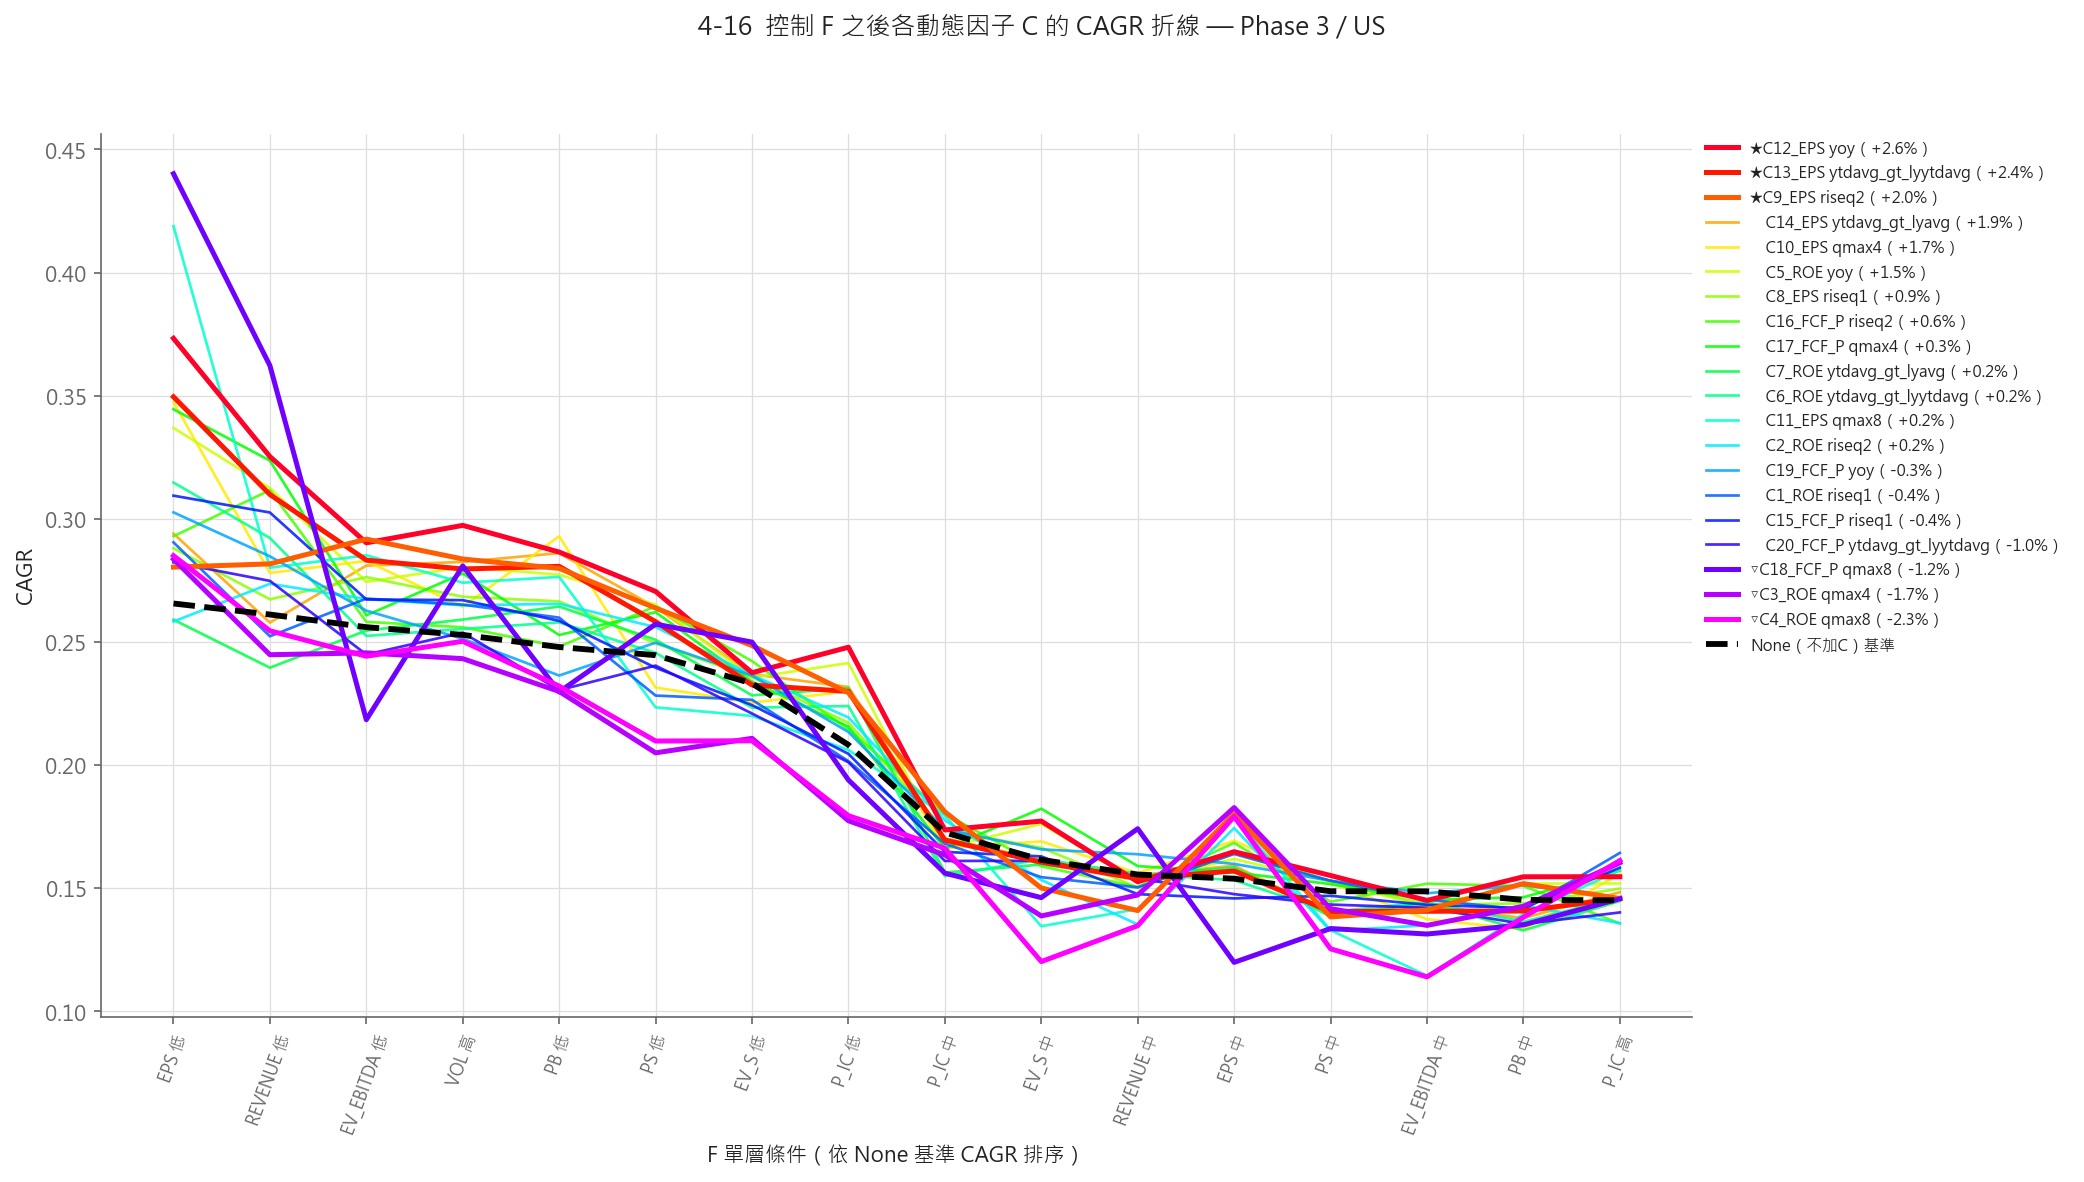

In [67]:
display(Image(f'../_analysis_outputs_phase3/{MARKET}_L3_fig4-16_controlled_C_lines.png'))


## 5. Phase 4：加入估值濾網 V

疊加 PE 相對估值濾網（v0=不濾、v1=濾），測試估值維度是否能再提升績效。
FCV 框架（F體質因子 × C動態條件 × V估值濾網）的最後一個維度：


In [68]:
%run phase4_valuation.py --market $MARKET --variant openSec --dry-run


[2026-08-24 22:17:00] === Phase 4 加入 V｜市場=US｜in-sample 至 2025-12-31 ===
[2026-08-24 22:17:00]     F 白名單=235｜C 狀態=21｜V=('v1',)（v0 沿用 Phase 3）
[2026-08-24 22:17:00]     預期共 4935 策略
[2026-08-24 22:17:00]     done  US_L4_openSec_M
[2026-08-24 22:17:00] dry-run：不執行。


拿掉 `--dry-run` 真的執行：


In [69]:
%run phase4_valuation.py --market $MARKET --variant openSec


[2026-08-24 22:17:00] === Phase 4 加入 V｜市場=US｜in-sample 至 2025-12-31 ===
[2026-08-24 22:17:00]     F 白名單=235｜C 狀態=21｜V=('v1',)（v0 沿用 Phase 3）
[2026-08-24 22:17:00]     預期共 4935 策略
[2026-08-24 22:17:00]     done  US_L4_openSec_M
[2026-08-24 22:17:00] 已完成，無待跑。


In [70]:
%run phase4_analyze.py --market $MARKET --variant openSec


基準 = 11.06%｜變體 = openSec

v0（Phase 3）4935 個｜v1（Phase 4）4935 個
依 Phase 2（openSec／universe）篩後：F 組合 235 個
成功配對 4935 組 v0/v1

計算 v1 的平均持股數 …
===== A. 加 V1 的整體效果 =====
  ΔCAGR 中位數 -3.65%｜平均 -4.71%｜為正比例 15.4%
  ΔMDD  中位數 -3.87%｜為正(風險下降)比例 22.5%
  持股數：v0 中位 83.7 → v1 中位 19.6

===== B. ΔCAGR × ΔMDD 四象限 =====
  ① 報酬升 風險降（雙贏）              332    6.7%
  ② 報酬升 風險升                  426    8.6%
  ③ 報酬降 風險降（換取穩定）            778   15.8%
  ④ 報酬降 風險升（雙輸）             3399   68.9%

===== C. 依 C 分組：加 V1 的 ΔCAGR（前5／後5）=====
                                 dCAGR中位  dMDD中位    n
C_v0                                                 
C20_FCF_P_DYN_ytdavg_gt_lyytdavg  -1.23%  -0.77%  235
C7_ROE_DYN_ytdavg_gt_lyavg        -1.53%  -3.36%  235
C5_ROE_DYN_yoy                    -2.03%  -3.32%  235
C6_ROE_DYN_ytdavg_gt_lyytdavg     -2.23%  -2.43%  235
C19_FCF_P_DYN_yoy                 -2.52%  -1.33%  235
  …
                               dCAGR中位   dMDD中位    n
C_v0                                                
C13_

看結果——最終候選策略表（前10筆，依CAGR排序），跟V濾網效果圖：

,strategy,F組合,C,CAGR,max_drawdown,win_ratio,持股數,V
0,PB_qb0of3__EPS_qb0of3__C11_EPS_DYN_qmax8__v0,PB_qb0of3__EPS_qb0of3,C11_EPS_DYN_qmax8,0.640985,-0.453438,0.569231,16.388316,v0
1,REVENUE_qb0of3__PS_qb0of3__C11_EPS_DYN_qmax8__v0,REVENUE_qb0of3__PS_qb0of3,C11_EPS_DYN_qmax8,0.591204,-0.389605,0.609195,16.579310,v0
2,EPS_qb0of3__ACCRUAL_qb0of3__C11_EPS_DYN_qmax8__v0,EPS_qb0of3__ACCRUAL_qb0of3,C11_EPS_DYN_qmax8,0.560891,-0.494012,0.536033,22.615120,v0
3,EV_S_qb0of3__EPS_qb0of3__C11_EPS_DYN_qmax8__v0,EV_S_qb0of3__EPS_qb0of3,C11_EPS_DYN_qmax8,0.549509,-0.586201,0.580262,11.754325,v0
4,P_IC_qb0of3__EPS_qb0of3__C10_EPS_DYN_qmax4__v0,P_IC_qb0of3__EPS_qb0of3,C10_EPS_DYN_qmax4,0.539486,-0.728427,0.563998,22.865132,v0
5,REVENUE_qb0of3__PS_qb0of3__C9_EPS_DYN_riseq2__v0,REVENUE_qb0of3__PS_qb0of3,C9_EPS_DYN_riseq2,0.532159,-0.586272,0.580981,49.165584,v0
6,EPS_qb0of3__ROE_qb2of3__C11_EPS_DYN_qmax8__v0,EPS_qb0of3__ROE_qb2of3,C11_EPS_DYN_qmax8,0.519752,-0.644120,0.565269,12.319588,v0
7,REVENUE_qb0of3__PS_qb0of3__C14_EPS_DYN_ytdavg_...,REVENUE_qb0of3__PS_qb0of3,C14_EPS_DYN_ytdavg_gt_lyavg,0.519159,-0.469156,0.599571,48.630000,v0
8,REVENUE_qb0of3__PS_qb0of3__C12_EPS_DYN_yoy__v0,REVENUE_qb0of3__PS_qb0of3,C12_EPS_DYN_yoy,0.515551,-0.500687,0.579325,48.830000,v0
9,REVENUE_qb0of3__PS_qb0of3__C10_EPS_DYN_qmax4__v0,REVENUE_qb0of3__PS_qb0of3,C10_EPS_DYN_qmax4,0.513791,-0.582926,0.590071,28.868852,v0


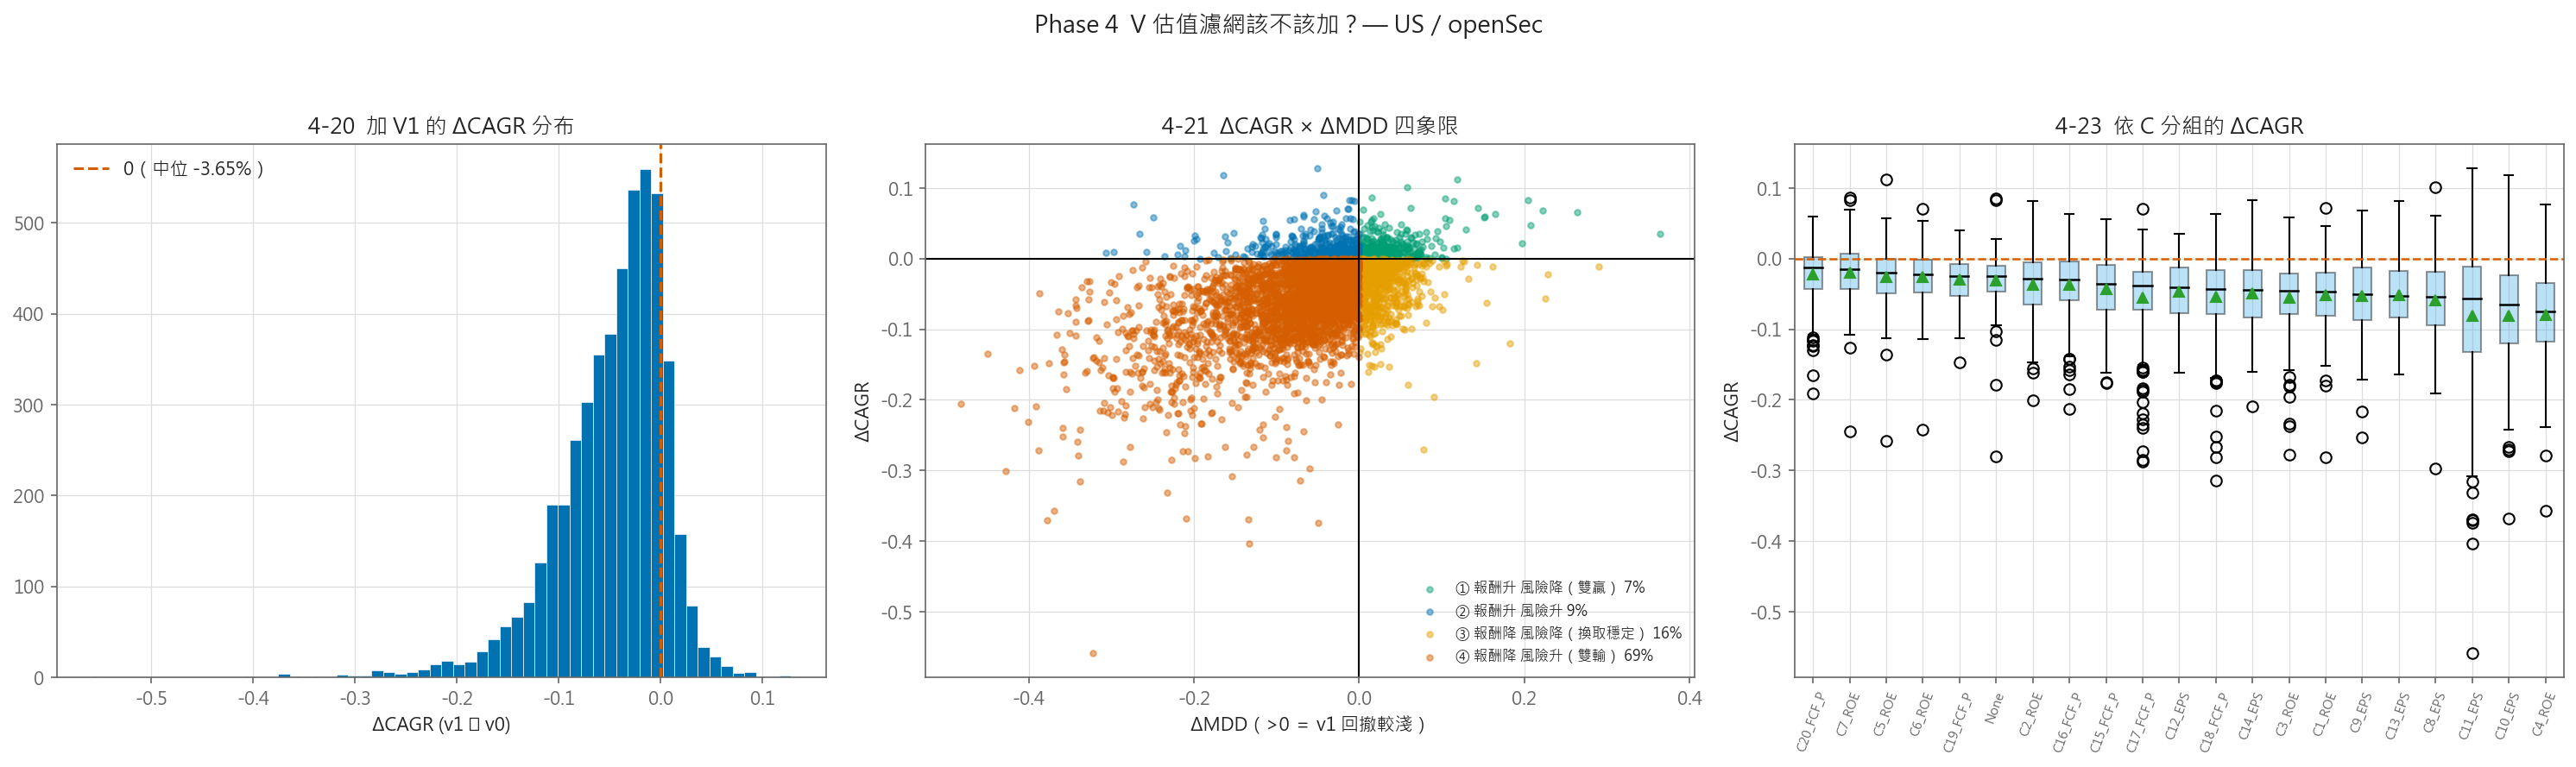

In [71]:
df = pd.read_csv(f'../_analysis_outputs_phase4/{MARKET}_L4_openSec_final_candidates.csv')
display(df.sort_values('CAGR', ascending=False).head(10))
display(Image(f'../_analysis_outputs_phase4/{MARKET}_L4_openSec_V_effect.png'))


## 6. 完整圖鑑（18張圖）

`build_atlas.py` 把 Phase 3（v0）與 Phase 4（v1）的結果合併，產出一組共18張圖的完整圖鑑，
涵蓋策略貢獻分解、F1×F2熱力圖、C條件分布、V0/V1比較等面向。需要 Phase 3、Phase 4 都已執行完：


In [72]:
%run build_atlas.py --market $MARKET --variant openSec


=== 第四章圖鑑｜US／openSec ===
>> 合併 US_L3_openSec_M（4935 個 v0）+ US_L4_openSec_M（4935 個 v1）= 9870 個策略
>> [US_ATLAS_openSec_M] 讀 stats.parquet …
   策略數=9870｜pair=9072｜single=798｜因子=['EPS', 'EV_EBITDA', 'EV_S', 'PB', 'PS', 'P_IC', 'REVENUE', 'VOL']
>> 4-2 Top10 熱力圖
>> 4-3/4-4 代表策略解剖（P_IC_qb0of3__EPS_qb0of3__C11_EPS_DYN_qmax8__v0）
>> 4-12 單層F CAGR盒鬚圖（依中位數排序）
>> 4-13 F1×F2 統一熱力圖
>> 4-15 不控制F的C盒鬚圖（反例）
>> 4-16 主入口：統一F軸的C折線
>> 4-17 各C的F1×F2熱力圖小圖組
>> V0/V1 配對 → 4-20/4-21/4-22/4-23
>> 4-18/4-24 自動選子樹深挖
>> 4-5~4-10 可信度（逐策略讀 trades.parquet，較耗時）
   [credibility:top25%] 掃 2468 個策略的 trades.parquet …
      1000/2468（237s）
      2000/2468（482s）
   [credibility:top25%] 完成，596s
   [credibility:top50%] 掃 4935 個策略的 trades.parquet …
      1000/4935（162s）
      2000/4935（306s）
      3000/4935（467s）
      4000/4935（673s）
   [credibility:top50%] 完成，885s
   → credibility_metrics_top50.parquet 已存

>> [US_ATLAS_openSec_M] 完成，圖表 18 張，總耗時 1490s → D:\git\stock_factor_lab\_analysis_outputs\US_ATLAS_openSec_M\figures
   - 

4-10_effective_n.png


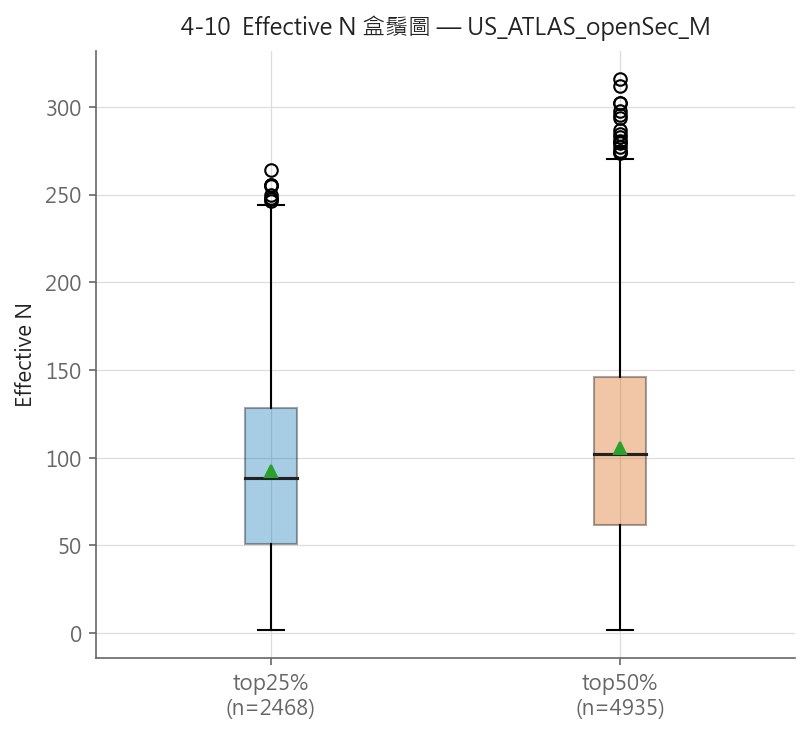

4-12_factor_boxplot.png


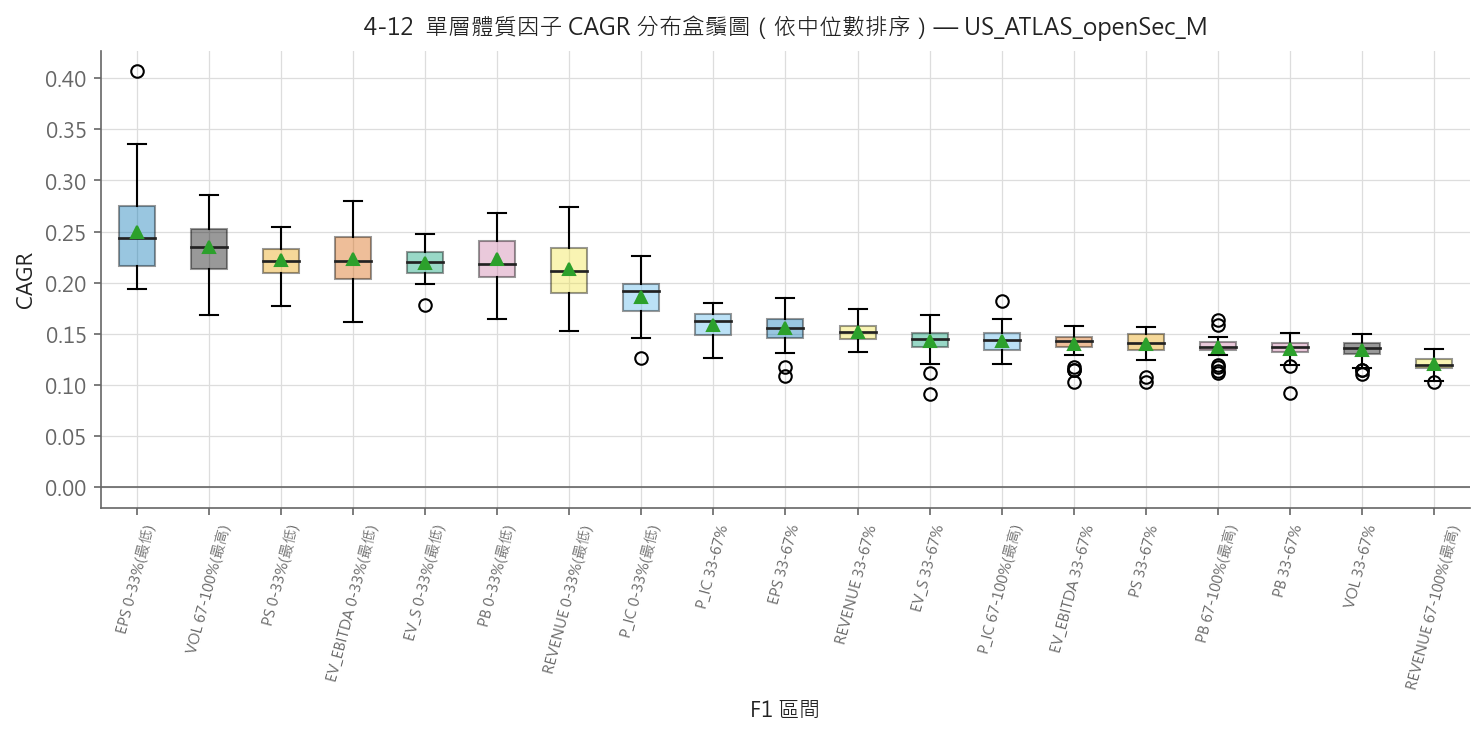

4-13_F1xF2_heatmap.png


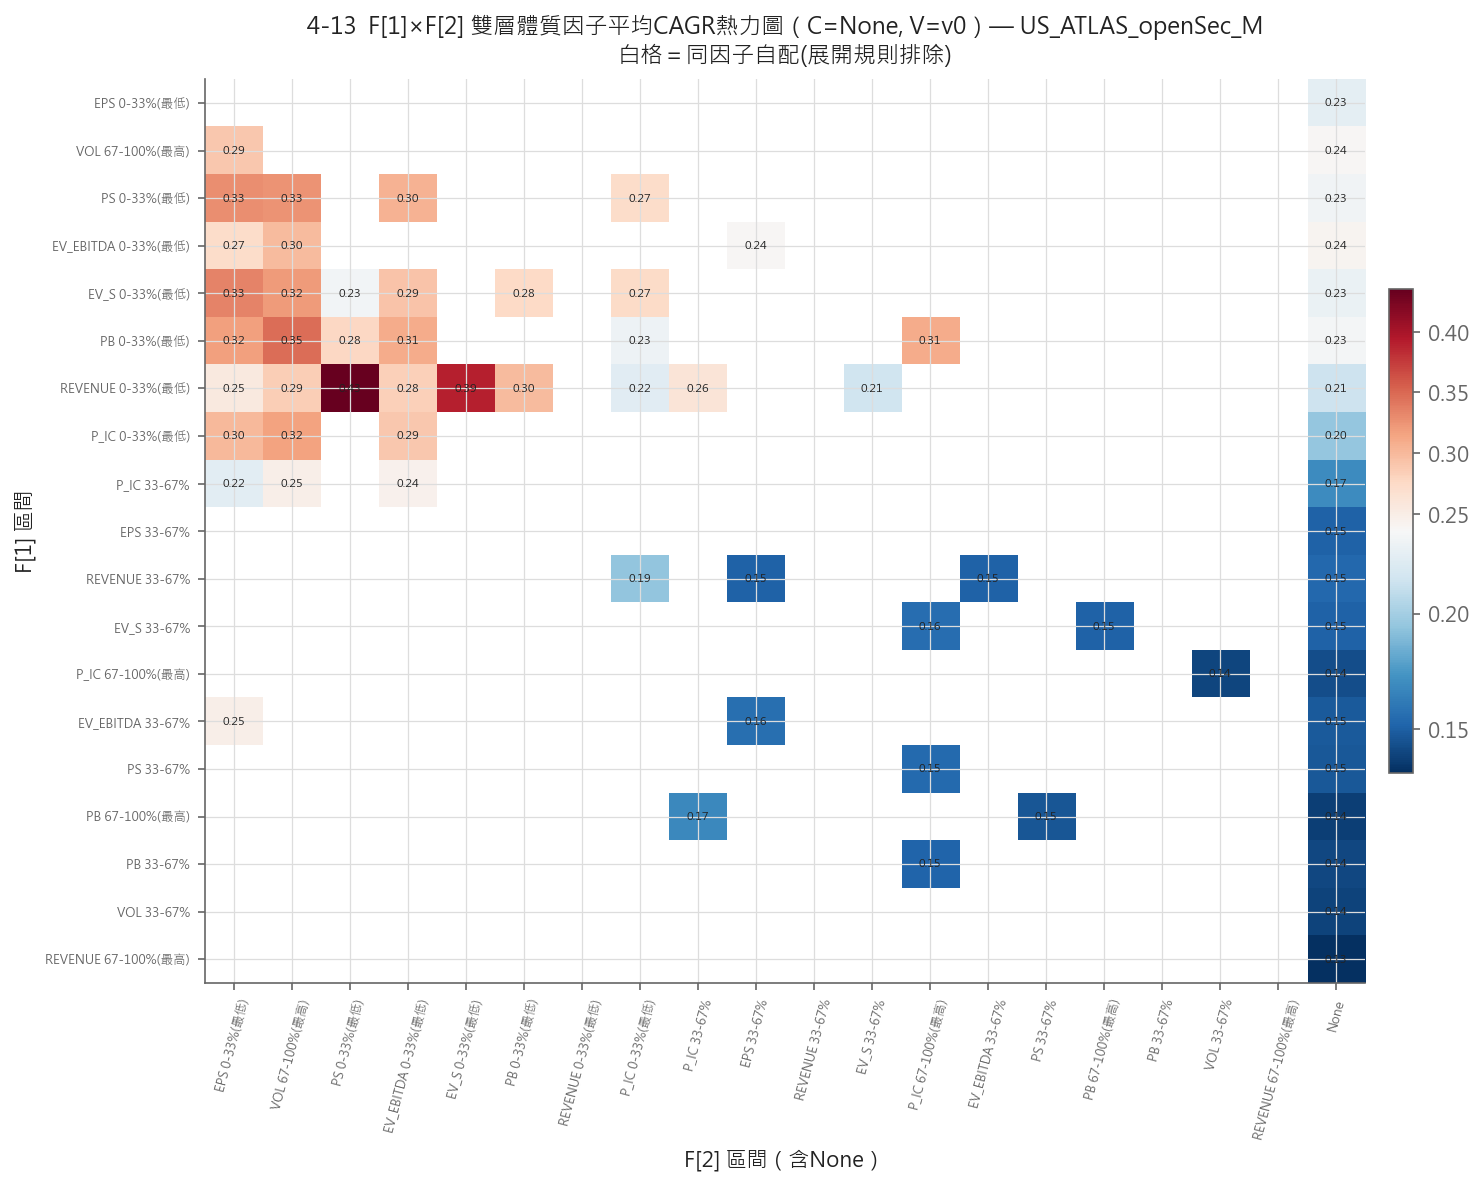

4-15_uncontrolled_C.png


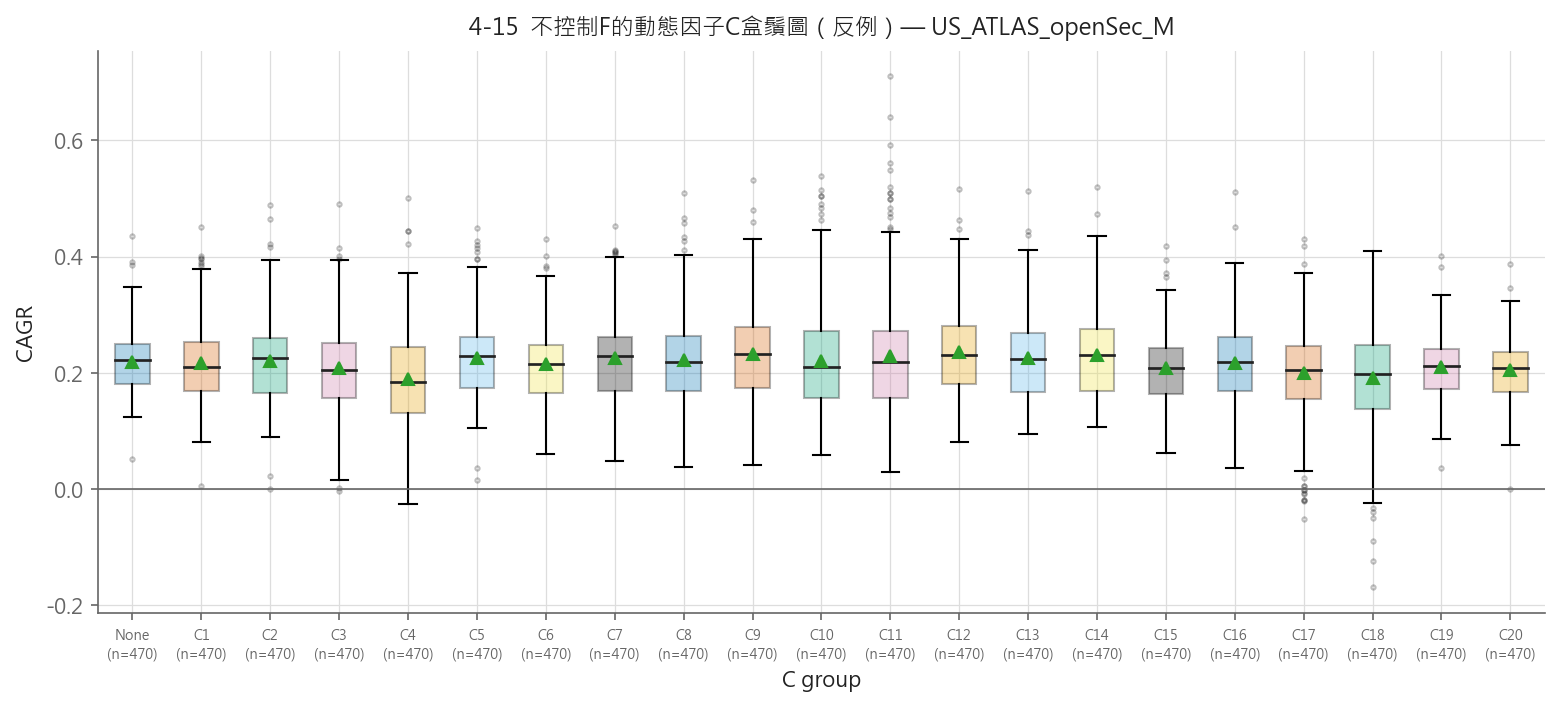

4-16_controlled_C_lines.png


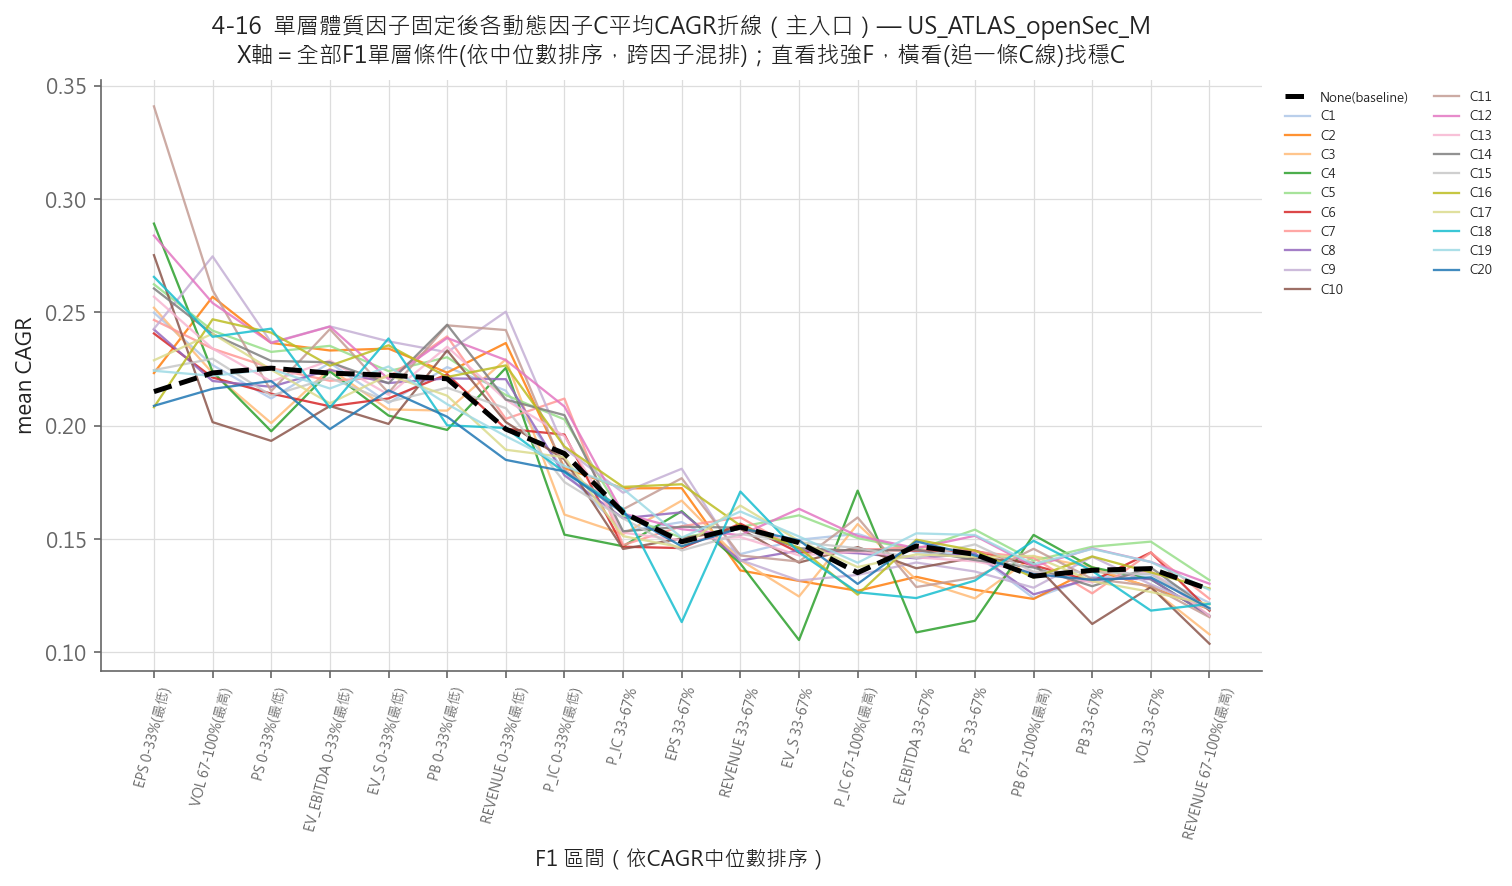

4-17_F1xF2_by_C_grid.png


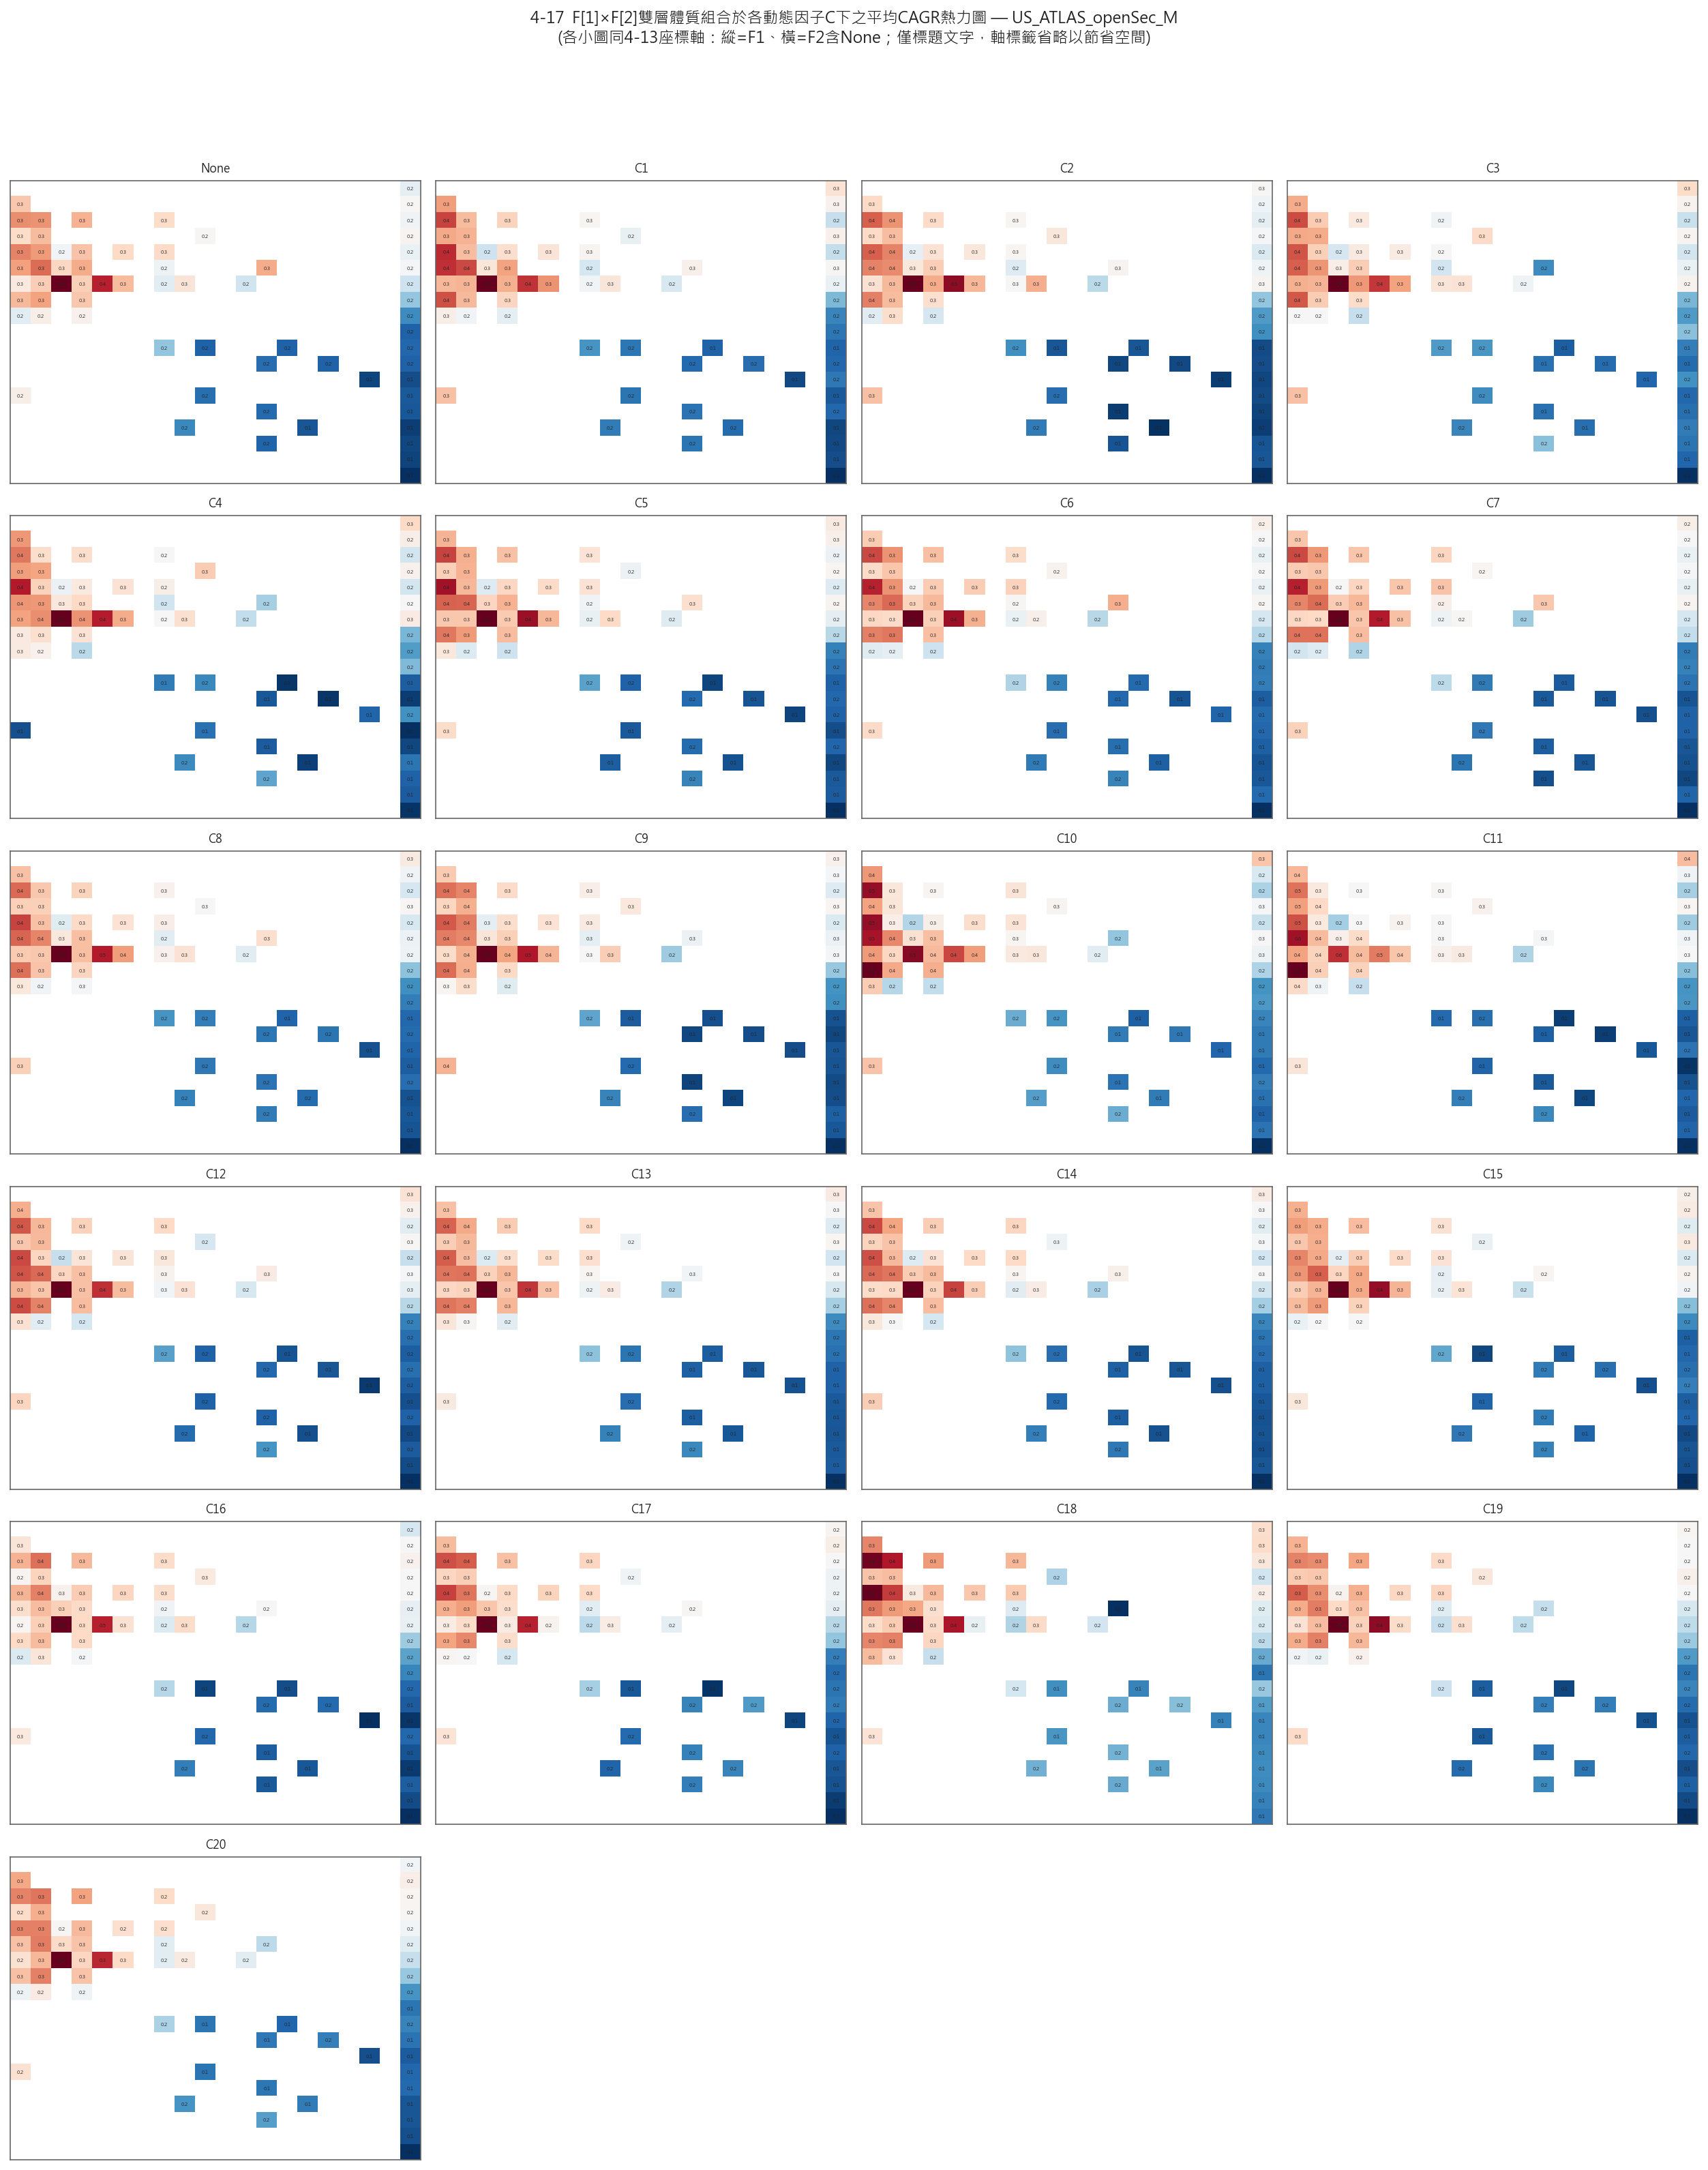

4-18_subtree_C_distribution.png


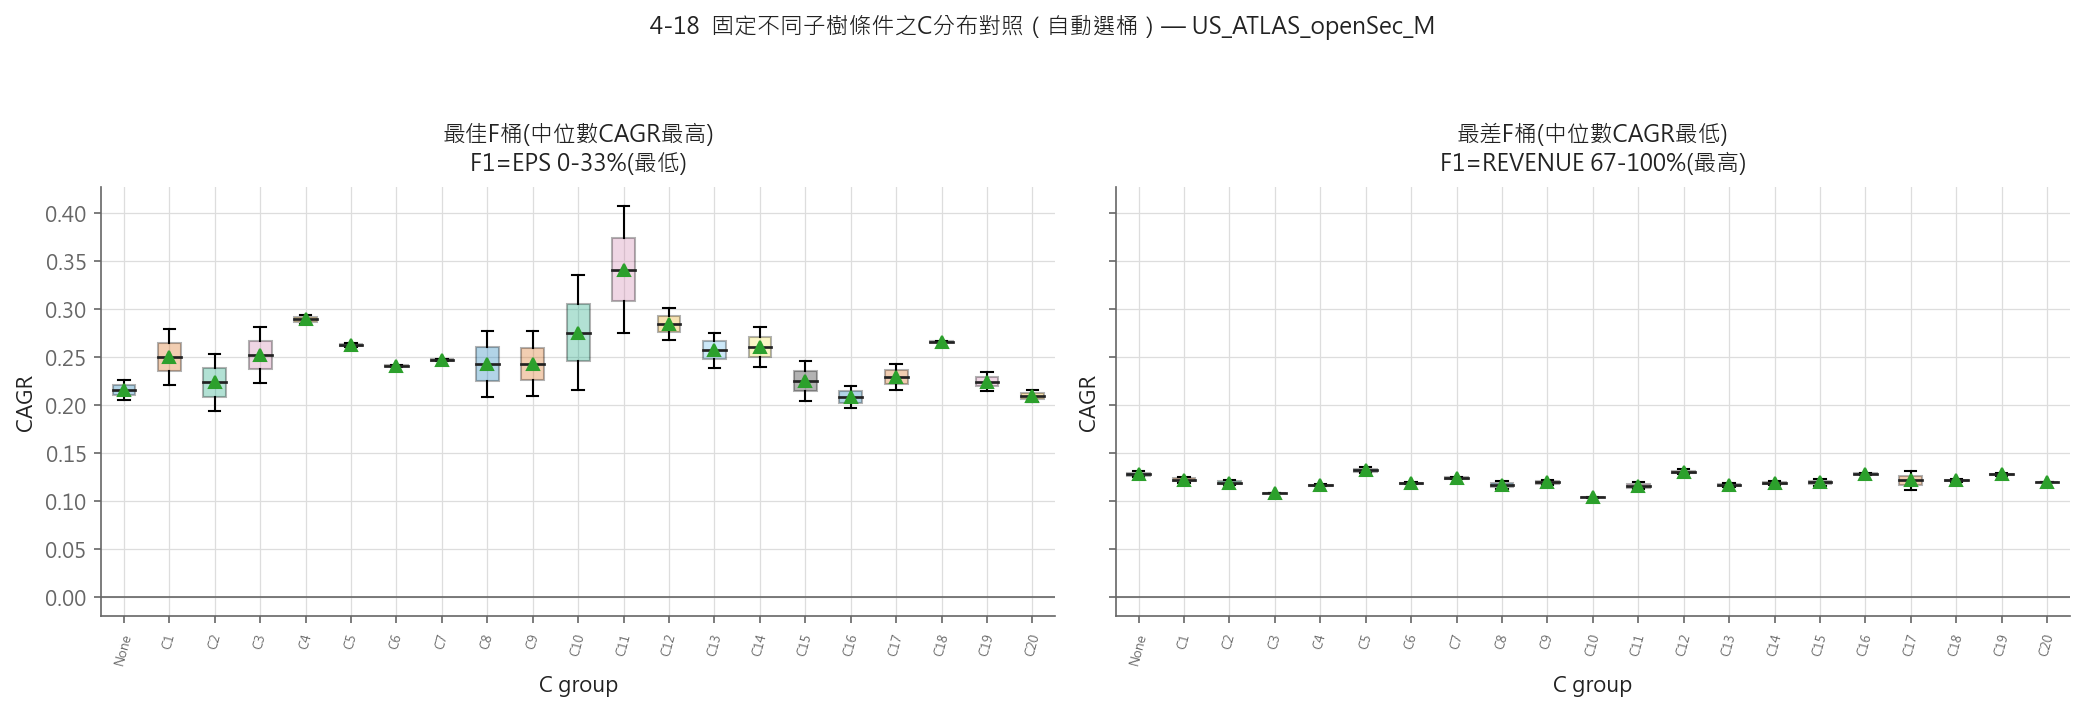

4-20_dCAGR_distribution.png


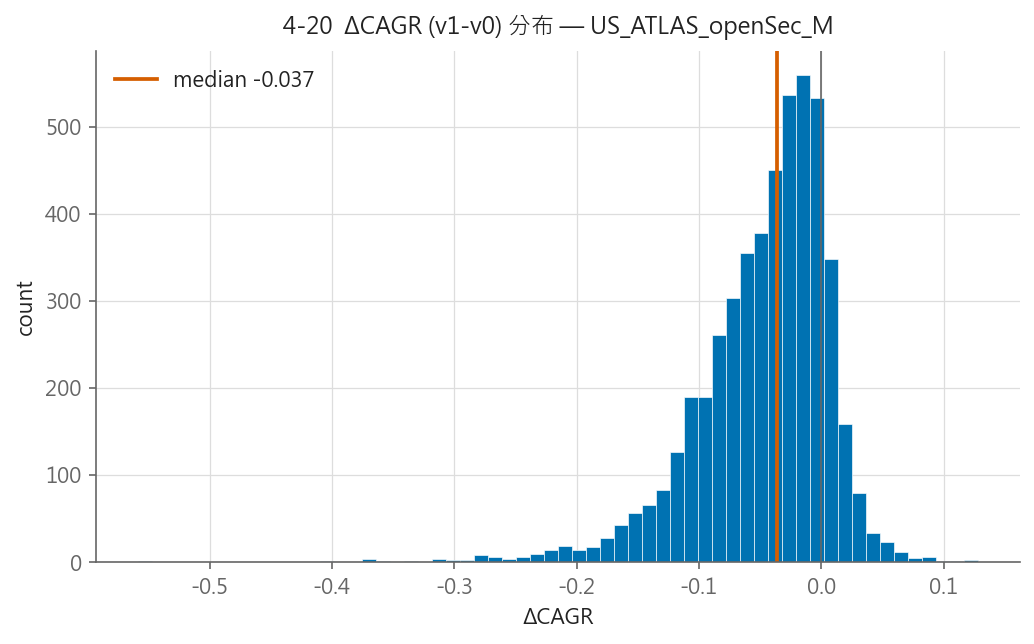

4-21_dCAGR_dMDD_quadrant.png


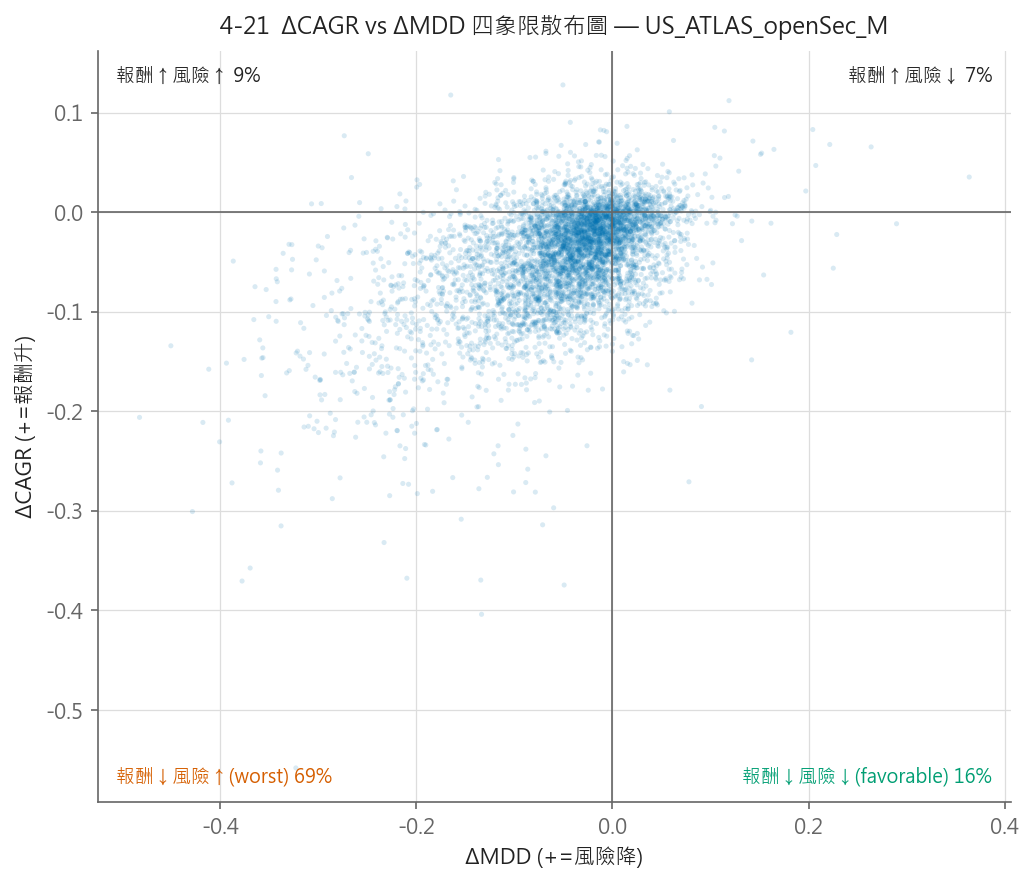

4-22_V0_V1_by_F_bucket.png


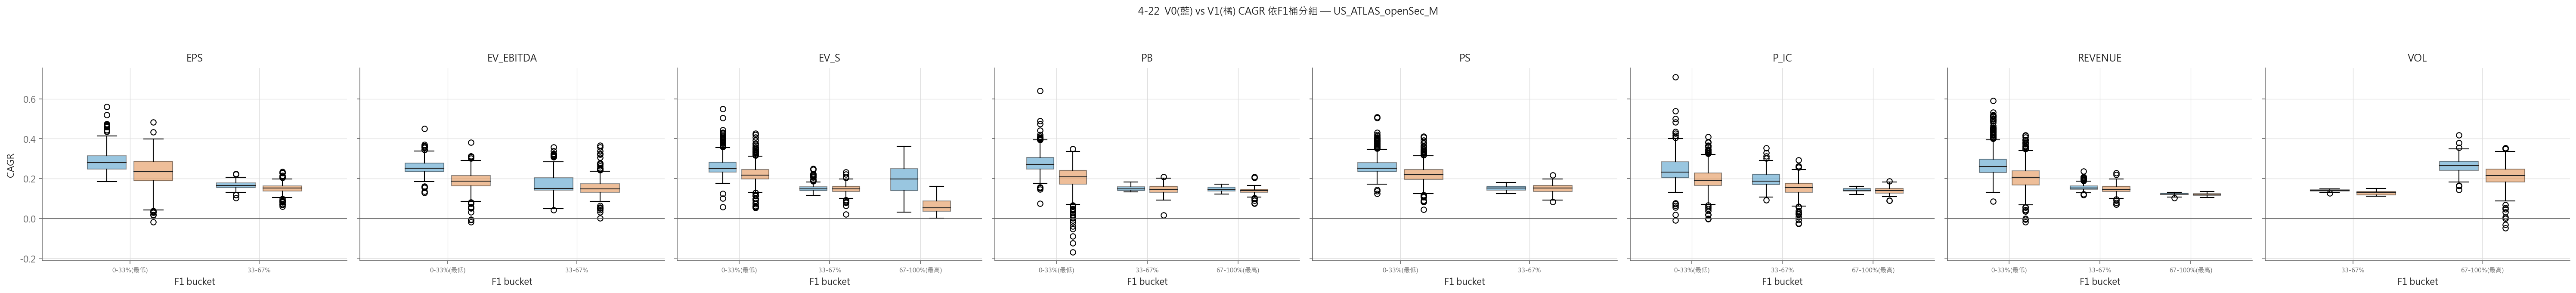

4-23_V0_V1_by_C.png


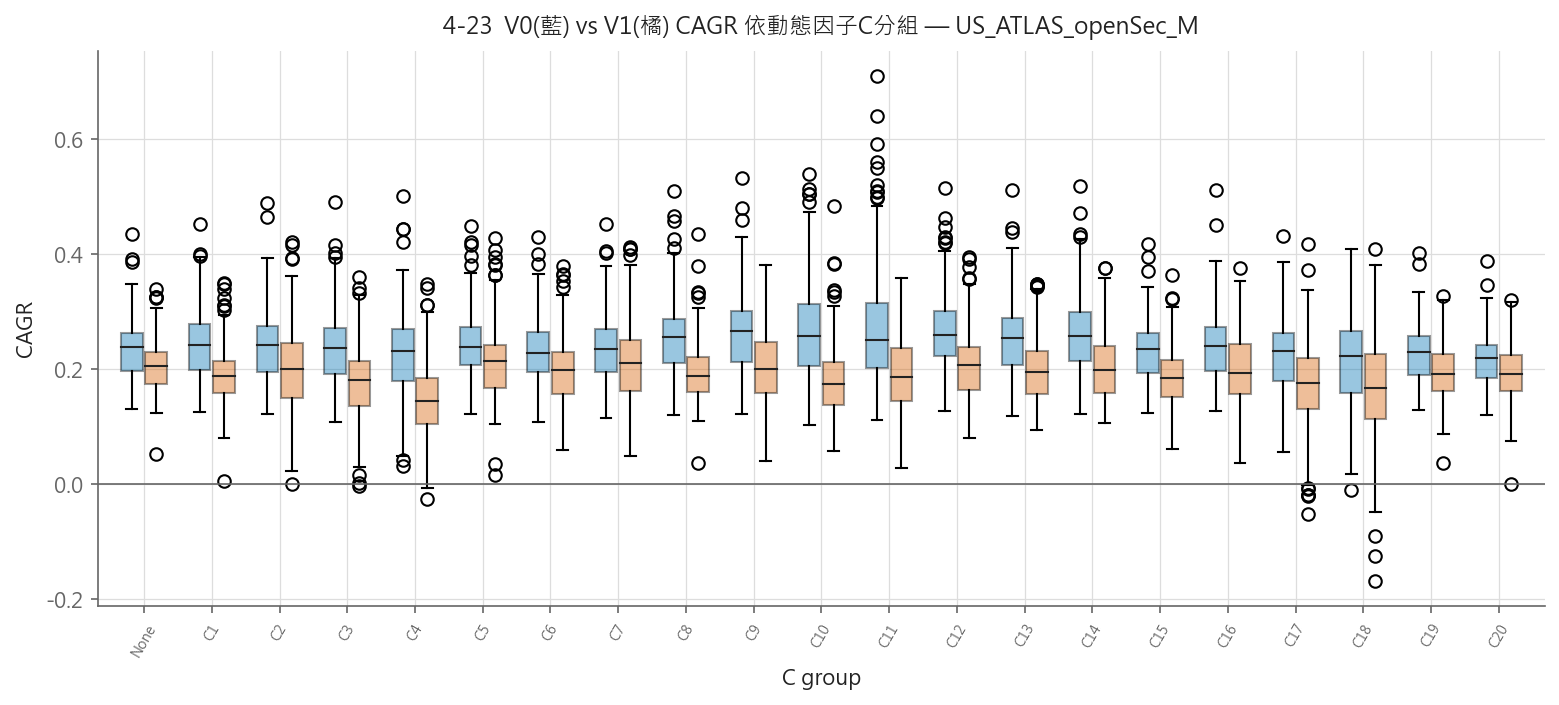

4-24_subtree_V0_V1_by_C.png


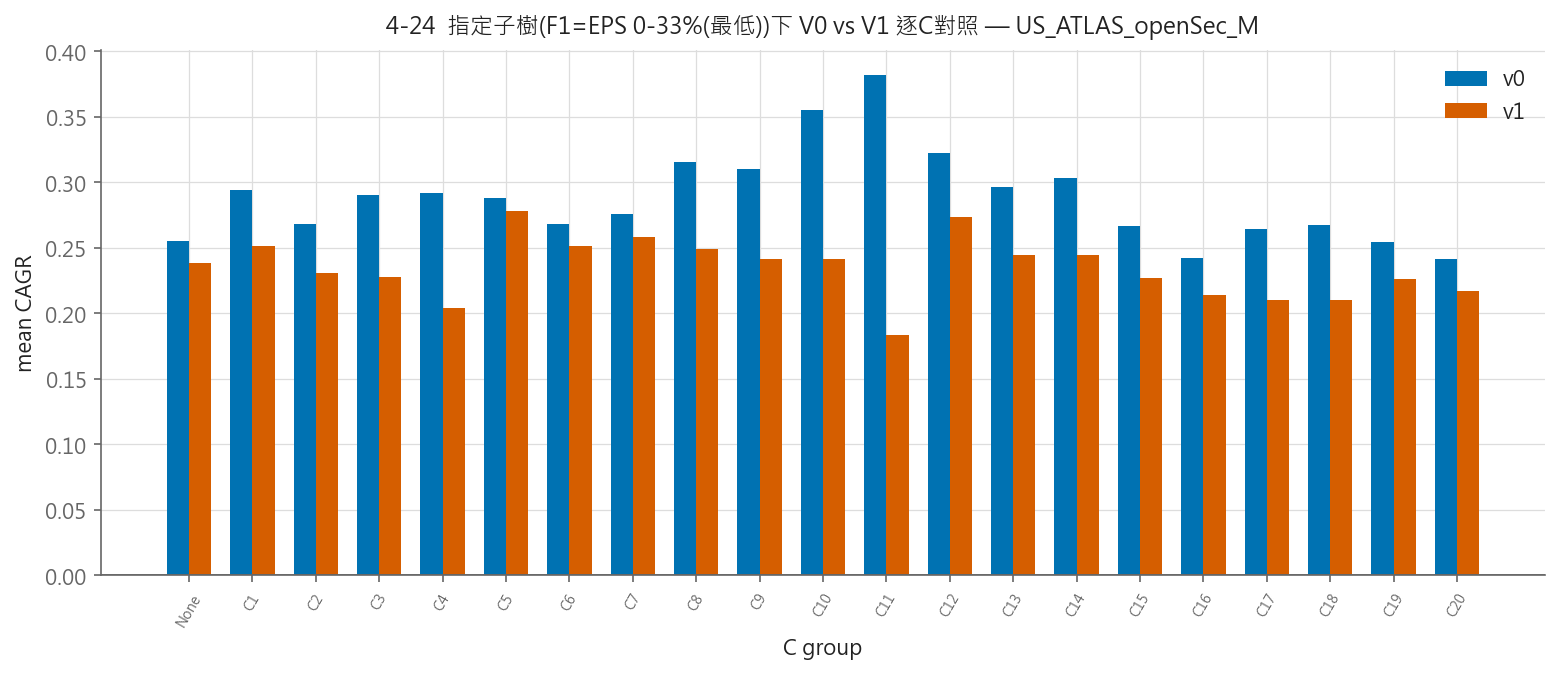

4-2_top10_heatmap.png


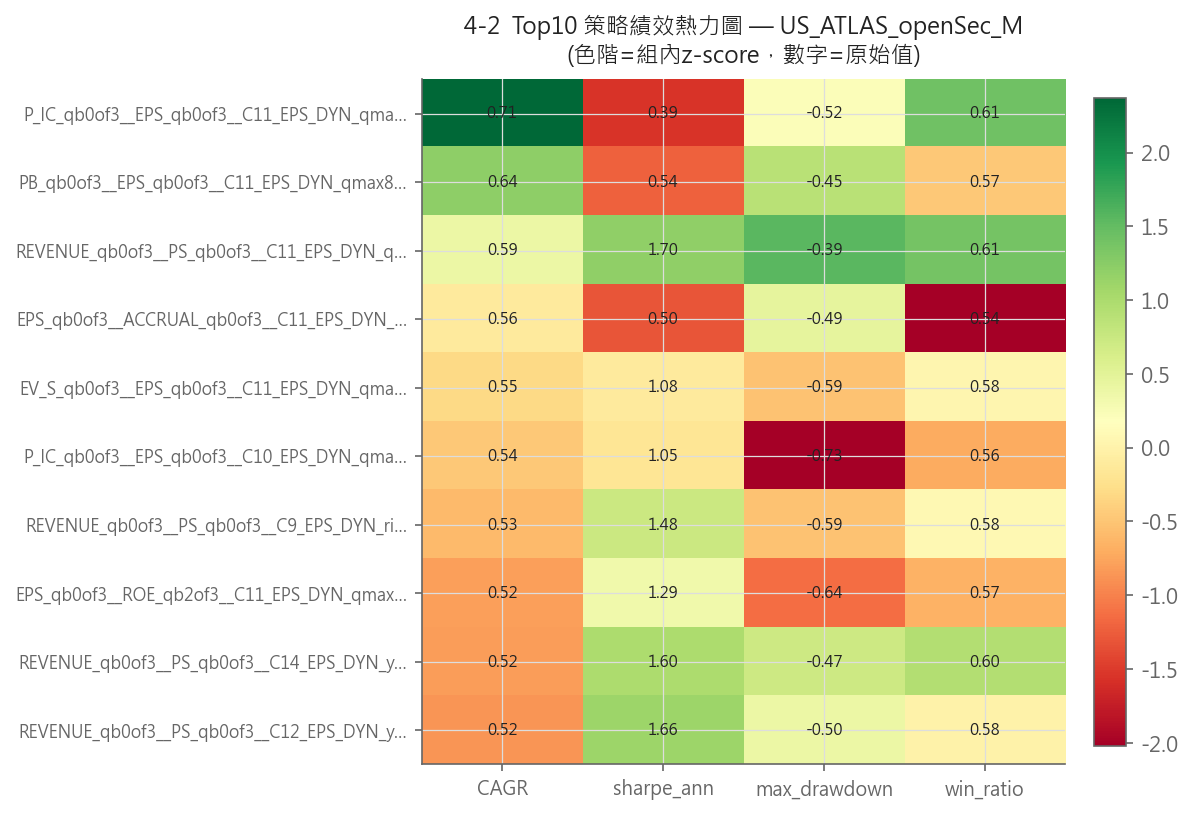

4-3_representative_dissection.png


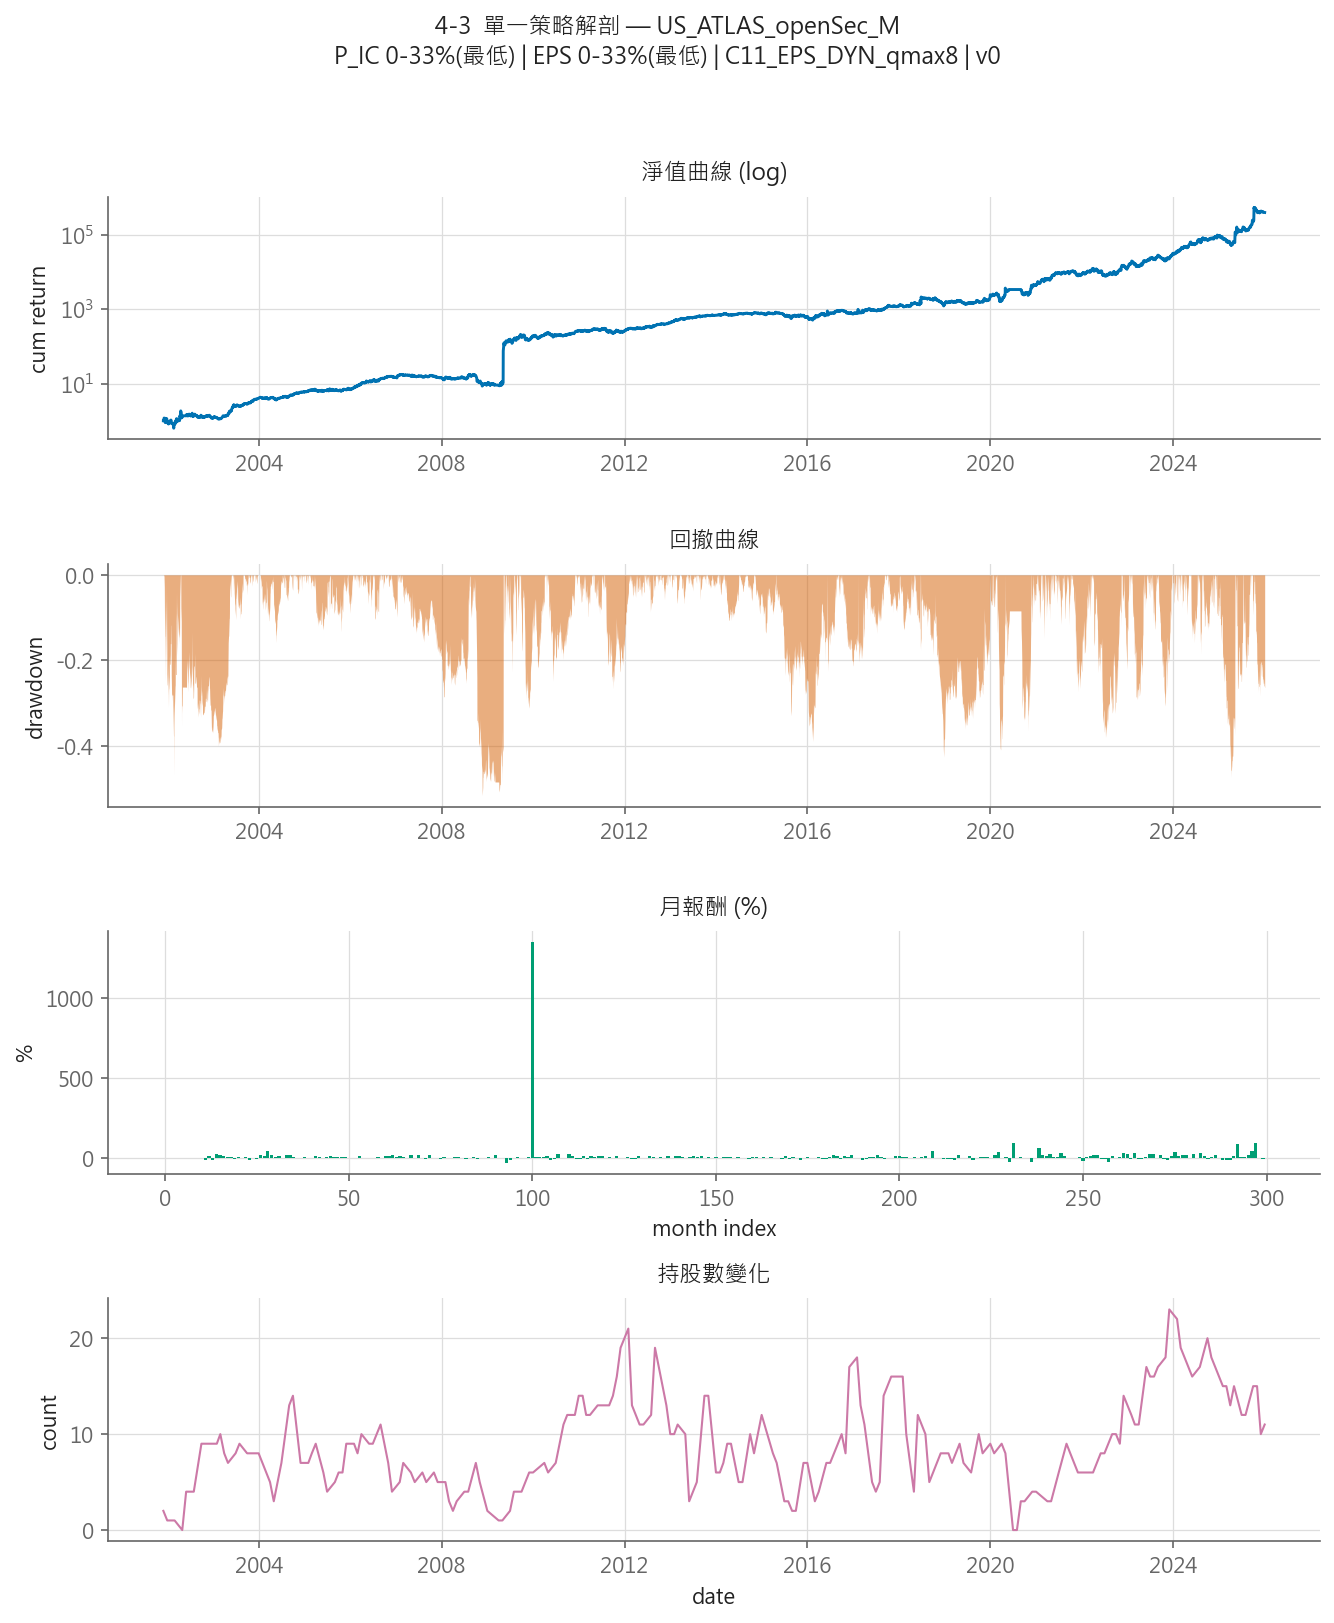

4-4_annual_contribution.png


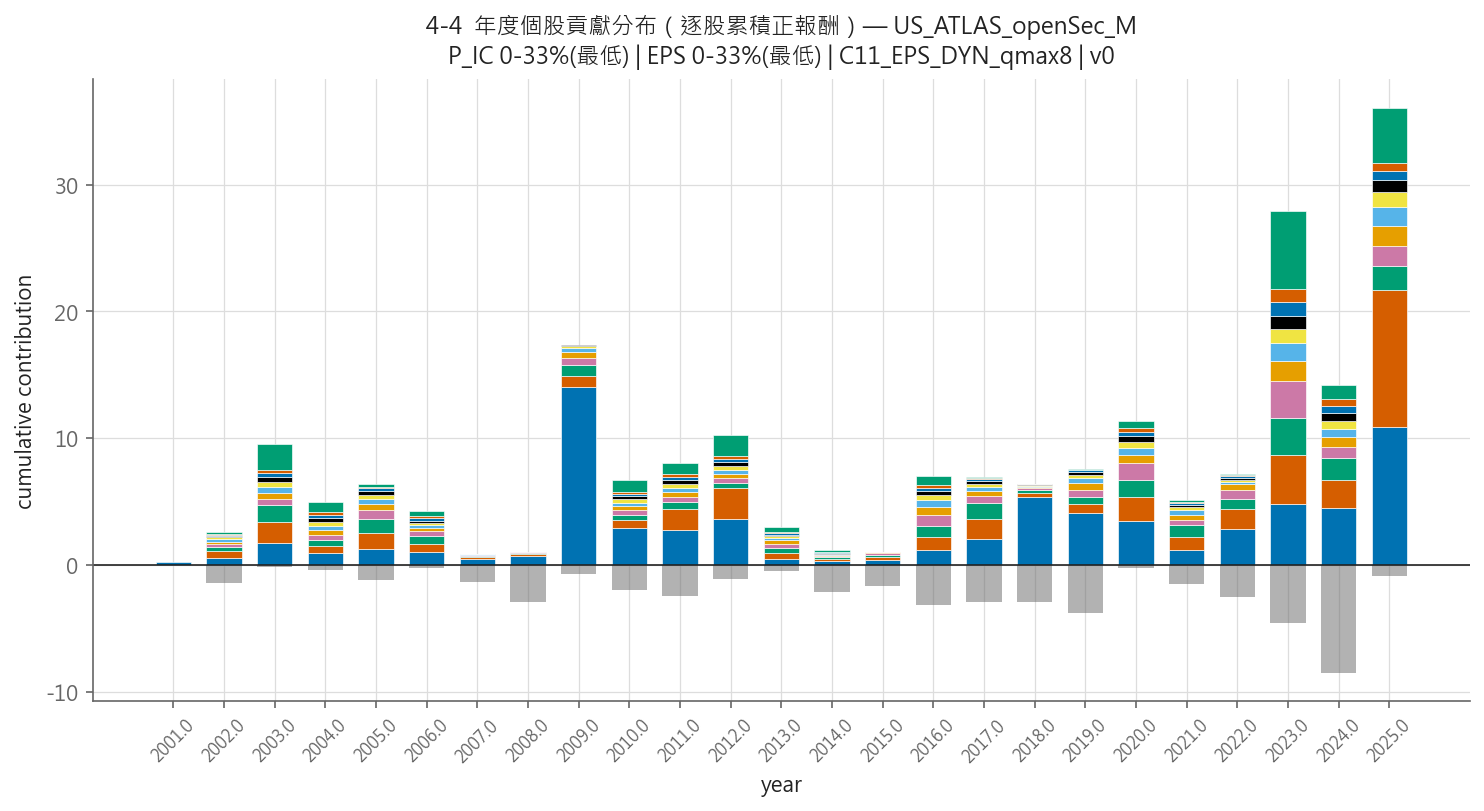

4-5_4-7_top1_frequency.png


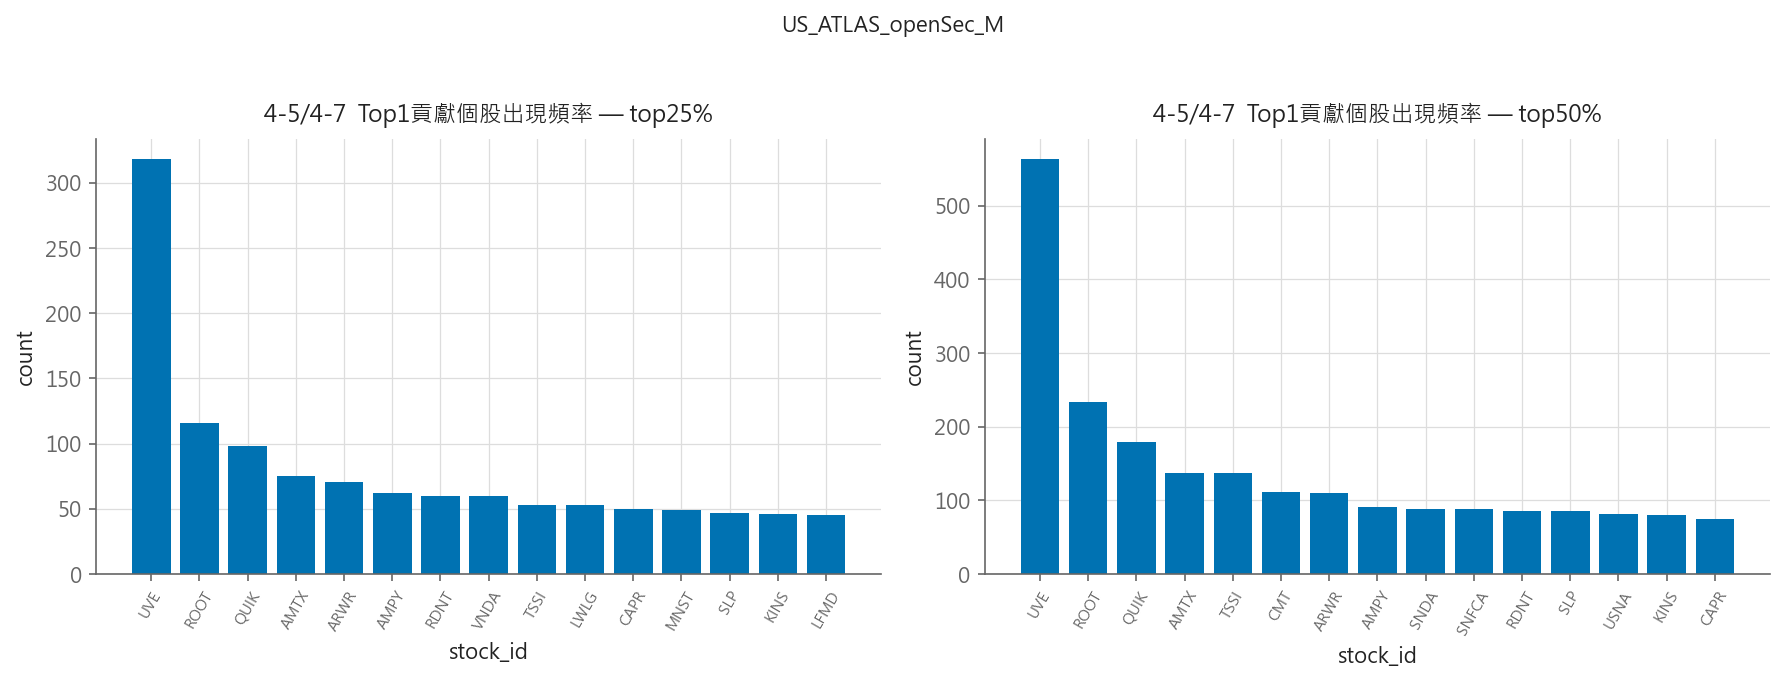

4-6_4-8_top1_share.png


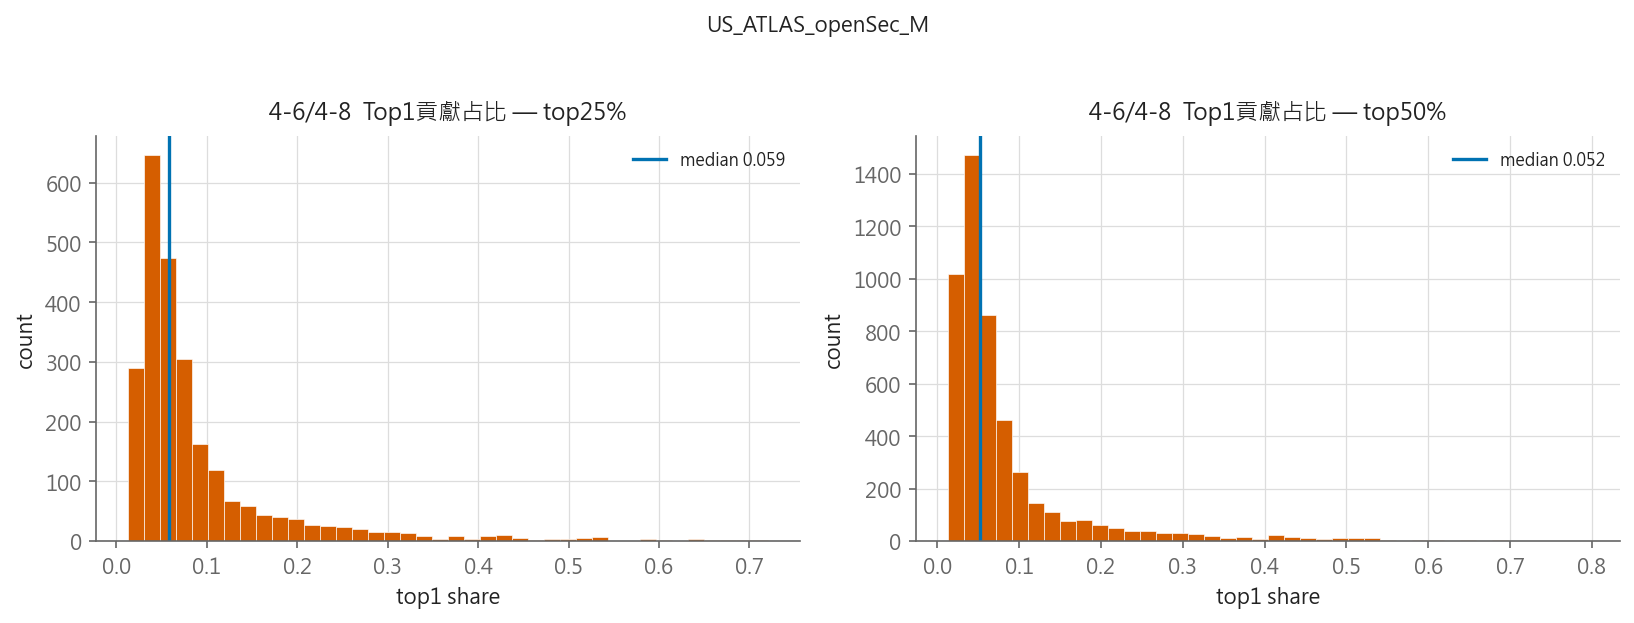

4-9_cumulative_contribution.png


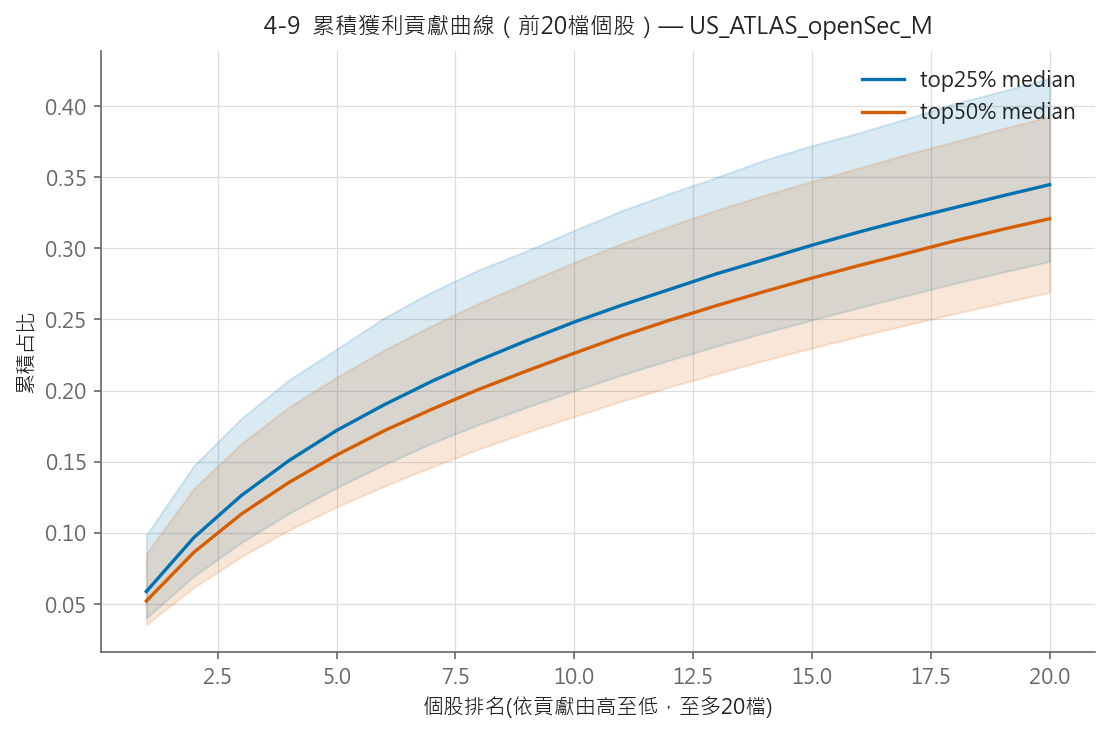

In [73]:
from pathlib import Path

fig_dir = Path(f'../_analysis_outputs_atlas/{MARKET}_openSec/figures')
for p in sorted(fig_dir.glob('*.png')):
    print(p.name)
    display(Image(str(p)))


## 7. 跑完之後

- 每個 Phase 的分析結果都在 `../_analysis_outputs_phase{1,2,3,4}/`，可以跟隨附的
  「參考結果」資料夾對照數字是否一致（同一份程式+同一份資料庫，Phase1-4是確定性
  流程，理論上應完全一致）。
- **切換市場**：改最上面「0.5 選擇市場」那格的 `MARKET` 變數即可，不用逐格修改，其餘流程完全相同。
